# 🫀 Brugada Syndrome Detection from ECG  
## Experimental Notebook: Traditional Features vs Deep Learning Embeddings

This notebook builds an **end-to-end pipeline** to detect Brugada Syndrome from ECG signals, with a focus on leads **V1-V3**, the clinically most relevant area for Brugada patterns.

## Notebook Goals
1. Prepare the ECG data and apply consistent **preprocessing**.
2. Compare three feature representations:
   - **Traditional**: handcrafted features based on morphology, statistics, spectral features, and wavelets.
   - **DL Embedding**: latent representations learned by a **BiGRU** model.
   - **Hybrid**: a combination of traditional features and embeddings.
3. Systematically evaluate many classification model combinations.
4. Select the final model with **Recall** as the top priority, because in the clinical context:
   - **False Negative (FN)** means a Brugada patient is missed.
   - **False Positive (FP)** can still be followed up through additional clinical evaluation.

## Workflow
```text
Raw ECG + metadata
→ label validation and V1-V3 lead selection
→ signal preprocessing
→ train/test split (held-out)
→ traditional feature extraction
→ BiGRU training and embedding extraction
→ construction of 3 feature sets
→ 5-fold cross-validation on the train set
→ model retraining on the full train set
→ final evaluation on the held-out test set
→ feature interpretation and blind inference on uncertain labels
```

## 0. Environment Setup

This section ensures that all dependencies are available before the experiment begins.  
The goal is simple: **make the notebook reproducible** in a new environment without changing the experimental logic.

In [45]:
# ============================================================
# CELL 0 — INSTALL
# ============================================================
import subprocess
for pkg in ['wfdb','scipy','scikit-learn','xgboost','lightgbm',
            'imbalanced-learn','PyWavelets','tqdm']:
    subprocess.run(['pip','install',pkg,'-q'], capture_output=True)
print('Done')


Done


## 1. Library Imports

At this stage, all main libraries are loaded, including:
- signal processing,
- machine learning,
- deep learning,
- visualization,
- and evaluation utilities.

The purpose of this stage is to prepare all components needed so the pipeline can run from start to finish in an integrated way.

In [46]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import os, warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

from scipy.signal import butter, filtfilt, medfilt, iirnotch, find_peaks, welch
from scipy.stats import kurtosis, skew

try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False

# ML
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb

# DL
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    import wfdb
    HAS_WFDB = True
except ImportError:
    HAS_WFDB = False

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyWavelets: {HAS_PYWT}')


Device: cuda | PyWavelets: True


## 2. Experiment Configuration

This cell defines the core experiment parameters, such as:
- the leads used (**V1-V3**),
- the number of cross-validation folds,
- the held-out test set proportion,
- and **manual threshold = 0.30**.

Defining the configuration from the start is important so that all subsequent stages follow the same experimental rules consistently.

In [47]:
# ============================================================
# CELL 2 — CONFIG
# ============================================================
BASE_DIR  = Path('.')
FILES_DIR = BASE_DIR / '/kaggle/input/datasets/christoperhw/brugada-syndrom/files/files'
META_CSV  = BASE_DIR / '/kaggle/input/datasets/christoperhw/brugada-syndrom/metadata.csv'

FS             = 100
N_SAMPLES      = 1200
ALL_LEADS      = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
LEAD_IDX       = {n:i for i,n in enumerate(ALL_LEADS)}
SELECTED_LEADS = ['V1','V2','V3']
SEL_IDX        = [LEAD_IDX[l] for l in SELECTED_LEADS]   # [6,7,8]

N_CV_FOLDS  = 5
TEST_SIZE   = 0.2

# ---- Manual threshold (rule-based, no OOF tuning) ----
# Based on observation: LR + DL_Embedding perform well below 0.2
# This threshold applies to ALL models during retraining + evaluation
MANUAL_THRESHOLD = 0.3

# BiGRU config
BIGRU_EPOCHS  = 40
BIGRU_LR      = 1e-3
BIGRU_HIDDEN  = 128
BIGRU_EMBED   = 128
BIGRU_DROPOUT = 0.3
BATCH_SIZE    = 16

print(f'Selected leads  : {SELECTED_LEADS} → indices {SEL_IDX}')
print(f'CV folds        : {N_CV_FOLDS}')
print(f'Test size       : {int(TEST_SIZE*100)}% held-out')
print(f'Manual threshold: {MANUAL_THRESHOLD} (rule-based, no tuning)')


Selected leads  : ['V1', 'V2', 'V3'] → indices [6, 7, 8]
CV folds        : 5
Test size       : 20% held-out
Manual threshold: 0.3 (rule-based, no tuning)


## 3. ECG Signal Reader Function

This cell prepares utilities to read raw ECG files and extract the required leads.

Its purpose is to make the data-loading process modular, so the notebook stays tidy and the subsequent signal processing can be applied consistently for every patient.

In [48]:
# ============================================================
# CELL 3 — ECG READER
# ============================================================
def parse_wfdb_header(hea_path):
    with open(hea_path) as f:
        lines = f.read().strip().split('\n')
    first = lines[0].split()
    n_leads, fs, n_samples = int(first[1]), int(first[2]), int(first[3])
    leads, gains, offsets = [], [], []
    for line in lines[1:n_leads+1]:
        parts = line.split()
        leads.append(parts[-1])
        g = parts[2]
        gains.append(float(g.split('(')[0].split('/')[0]))
        offsets.append(int(g.split('(')[1].split(')')[0]) if '(' in g else 0)
    return dict(fs=fs, n_samples=n_samples, n_leads=n_leads,
                leads=leads, gains=gains, offsets=offsets)

def read_ecg(pid, files_dir=FILES_DIR):
    base = Path(files_dir) / str(pid) / str(pid)
    if HAS_WFDB:
        try:
            rec = wfdb.rdrecord(str(base))
            return rec.p_signal, rec.fs, rec.sig_name
        except: pass
    info = parse_wfdb_header(str(base)+'.hea')
    raw  = np.fromfile(str(base)+'.dat', dtype=np.int16)
    sig  = raw.reshape(info['n_samples'], info['n_leads']).astype(float)
    for i in range(info['n_leads']):
        sig[:,i] = (sig[:,i]-info['offsets'][i]) / info['gains'][i]
    return sig, info['fs'], info['leads']


## 4. Signal Preprocessing

The preprocessing stage is applied so that the signals entering feature extraction and modeling are already in a cleaner and more stable condition.

Main steps applied:
- **Baseline correction** to reduce baseline wander.
- **50 Hz notch filtering** to suppress electrical interference.
- **Normalization** so the scale across leads is more comparable for modeling.

Clinically, this stage is important because we want to clean the noise **without damaging the morphology**, which is exactly where the main Brugada signal lies, especially around the ST segment and repolarization.

In [49]:
# ============================================================
# CELL 4 — PREPROCESSING
# ============================================================
def bandpass_filter(sig, lo=0.5, hi=40.0, fs=100, order=4):
    nyq = 0.5*fs
    b,a = butter(order, [lo/nyq, min(hi/nyq,0.99)], btype='band')
    return filtfilt(b, a, sig, axis=0)

def notch_filter(sig, freq=50.0, Q=30.0, fs=100):
    if freq >= fs/2: return sig
    b,a = iirnotch(freq/(fs/2), Q)
    return filtfilt(b, a, sig, axis=0)

def baseline_correction(sig, window_ms=200, fs=100):
    win = int(window_ms/1000*fs)
    win = win+1 if win%2==0 else win
    return sig - medfilt(sig, kernel_size=(win,1))

def normalize_per_lead(sig):
    out = sig.copy()
    for i in range(sig.shape[1]):
        x = sig[:,i]; s = x.std()
        out[:,i] = (x-x.mean())/s if s>1e-8 else x
    return out

def preprocess(sig_12lead, fs=100):
    sig = sig_12lead.copy().astype(float)
    sig = baseline_correction(sig, 200, fs)
    sig = notch_filter(sig, 50.0, fs=fs)
    sig = bandpass_filter(sig, 0.5, 40.0, fs=fs)
    sig = normalize_per_lead(sig)
    return sig

print('Preprocessing ready')


Preprocessing ready


## 5. Loading Metadata and All Signals

This cell combines patient metadata with valid ECG signals, then applies preprocessing to the full dataset.

What happens here:
- checking data consistency,
- separating the main label from uncertain labels,
- computing a class-distribution summary,
- and ensuring that only valid data proceeds to the modeling stage.

**Brief interpretation of the output:** the main dataset used for binary classification consists of **356 valid patients**, with **69 Brugada** and **287 Normal**, so the problem is indeed an **imbalanced classification** task. In addition, there are **7 patients with uncertain labels (blind / label=2)** stored for separate analysis, not for supervised training.

In [50]:
# ============================================================
# CELL 5 — LOAD METADATA + ALL SIGNALS
# ============================================================
meta        = pd.read_csv(META_CSV)
blind_meta  = meta[meta['brugada']==2].copy()
meta_main   = meta[meta['brugada'].isin([0,1])].copy().reset_index(drop=True)

print(f'Total       : {len(meta_main)} | Brugada={meta_main["brugada"].sum()} | Normal={(meta_main["brugada"]==0).sum()}')
print(f'Imbalance   : {(meta_main["brugada"]==0).sum()/meta_main["brugada"].sum():.1f}:1')
print(f'Blind (=2)  : {len(blind_meta)}')

signals_12   = {}   # pid -> (1200,12) preprocessed
signals_v123 = {}   # pid -> (1200,3)  V1-V3 only

print('\nLoading & preprocessing signals...')
for pid in tqdm(meta['patient_id'].values):
    try:
        raw,_,_ = read_ecg(pid)
        if raw.shape[0] < N_SAMPLES:
            raw = np.pad(raw, ((0,N_SAMPLES-raw.shape[0]),(0,0)))
        raw = raw[:N_SAMPLES,:]
        sig_p = preprocess(raw, FS)
        signals_12[pid]   = sig_p
        signals_v123[pid] = sig_p[:, SEL_IDX]
    except: pass

meta_main = meta_main[meta_main['patient_id'].isin(signals_v123)].reset_index(drop=True)
pids_all  = meta_main['patient_id'].values
y_all     = meta_main['brugada'].values
print(f'Valid: {len(meta_main)} patients')


Total       : 356 | Brugada=69 | Normal=287
Imbalance   : 4.2:1
Blind (=2)  : 7

Loading & preprocessing signals...


100%|██████████| 363/363 [00:04<00:00, 85.61it/s]

Valid: 356 patients


## 6. Train/Test Split (Held-Out Test)

The data is split early into:
- a **train set** for model development,
- a **held-out test set** for final evaluation.

Why is the split done before feature engineering and evaluation?
- to prevent **data leakage**,
- to ensure the test set truly simulates **new patients never seen by the model**.

**Output interpretation:** the train set contains **284 patients** and the test set contains **72 patients**. The Brugada distribution in the test set is preserved through stratified splitting, so the final evaluation remains representative.

Train: 284 (55 Brugada, 229 Normal)
Test : 72 (14 Brugada, 58 Normal)


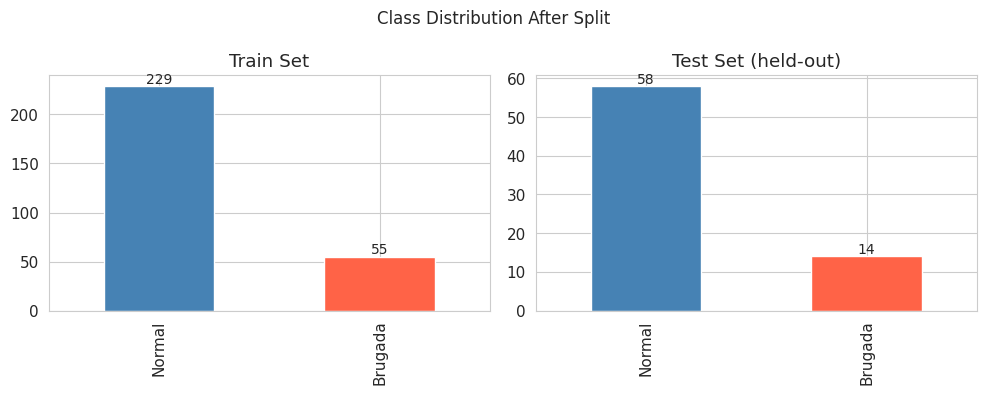

In [51]:
# ============================================================
# CELL 6 — TRAIN/TEST SPLIT (HELD-OUT)
# Split first before anything else - the test set is never touched during CV
# ============================================================
idx_all = np.arange(len(pids_all))
idx_tr, idx_te = train_test_split(
    idx_all, test_size=TEST_SIZE, stratify=y_all, random_state=SEED
)

pids_tr = pids_all[idx_tr];  pids_te = pids_all[idx_te]
y_tr    = y_all[idx_tr];     y_te    = y_all[idx_te]

print(f'Train: {len(pids_tr)} ({y_tr.sum()} Brugada, {(y_tr==0).sum()} Normal)')
print(f'Test : {len(pids_te)} ({y_te.sum()} Brugada, {(y_te==0).sum()} Normal)')

fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax, split_y, title in zip(axes, [y_tr, y_te], ['Train Set','Test Set (held-out)']):
    pd.Series(split_y).map({0:'Normal',1:'Brugada'}).value_counts().plot(
        kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
    ax.set_title(title); ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)
plt.suptitle('Class Distribution After Split', fontsize=12)
plt.tight_layout(); plt.show()


## 7. Traditional Feature Extraction

At this stage, the signal is transformed into handcrafted features that are more interpretable.  
The extracted features include:
- simple statistics,
- beat morphology,
- spectral energy,
- wavelets,
- and indicators directly related to Brugada patterns.

The goal of this stage is to encode **clinical domain knowledge** into a numeric form, so the model learns from patterns that are physiologically relevant, not only from abstract representations.

**Output interpretation:** **153 traditional features** are produced, which is rich enough to represent the V1-V3 signals without sacrificing interpretability.

In [52]:
# ============================================================
# CELL 7 — FEATURE ENGINEERING: TRADITIONAL
# simple stats + beat morphology + spectral/wavelet features from V1-V2-V3
# ============================================================

def summarize_array(arr, prefix, stats=("mean","std","min","max")):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    out = {}
    if arr.size == 0:
        for s in stats: out[f"{prefix}_{s}"] = np.nan
        return out
    if "mean" in stats: out[f"{prefix}_mean"] = np.mean(arr)
    if "std"  in stats: out[f"{prefix}_std"]  = np.std(arr)
    if "min"  in stats: out[f"{prefix}_min"]  = np.min(arr)
    if "max"  in stats: out[f"{prefix}_max"]  = np.max(arr)
    return out


def detect_r_peaks(sample_v123, fs=100):
    for lead_idx in [1, 0, 2]:   # V2, V1, V3
        sig = np.abs(sample_v123[:, lead_idx])
        peaks, _ = find_peaks(
            sig,
            distance=max(1, int(0.4*fs)),
            prominence=max(0.15, 0.5*np.std(sig))
        )
        if len(peaks) >= 2:
            return peaks, lead_idx
    return np.array([], dtype=int), None


def extract_lead_features_per_beat(sig, r_peaks, fs=100):
    pre  = int(0.20*fs)
    post = int(0.40*fs)

    store = {k:[] for k in [
        'r_amp','j_amp','st40_amp','st80_amp','t_peak_amp','t_polarity',
        'r_to_j_ratio','st_slope_0_40','st_slope_40_80',
        'st_area','stt_area','qrs_energy','qrs_area','qrs_width_ms'
    ]}

    for rp in r_peaks:
        s, e = rp-pre, rp+post
        if s < 0 or e > len(sig): continue
        beat  = sig[s:e]
        r_loc = pre

        baseline = np.median(beat[:max(1,r_loc-int(0.05*fs))])
        r_amp    = beat[r_loc] - baseline

        j_loc    = r_loc + int(0.04*fs)
        st40_loc = r_loc + int(0.08*fs)
        st80_loc = r_loc + int(0.12*fs)
        t_start  = r_loc + int(0.15*fs)
        t_end    = min(r_loc + int(0.35*fs), len(beat)-1)

        if j_loc >= len(beat): continue
        if st80_loc >= len(beat): st80_loc = len(beat)-1

        j_amp    = beat[j_loc]  - baseline
        st40_amp = beat[min(st40_loc,len(beat)-1)] - baseline
        st80_amp = beat[st80_loc] - baseline

        t_seg  = beat[t_start:t_end] if t_end>t_start else np.array([0.])
        t_peak = float(np.max(np.abs(t_seg)))
        t_pol  = 1.0 if t_seg[np.argmax(np.abs(t_seg))]>0 else -1.0

        dt = int(0.04*fs) if int(0.04*fs)>0 else 1
        slope_0_40  = (st40_amp - j_amp) / dt
        slope_40_80 = (st80_amp - st40_amp) / dt

        st_area  = np.trapz(beat[j_loc:st80_loc]-baseline) if st80_loc>j_loc else 0.
        stt_area = np.trapz(beat[j_loc:t_end]-baseline)    if t_end>j_loc    else 0.

        qrs_s = max(r_loc-int(0.05*fs),0)
        qrs_e = j_loc
        qrs_seg = beat[qrs_s:qrs_e] if qrs_e>qrs_s else np.array([0.])

        thr = 0.5*abs(r_amp)
        if thr > 0:
            l,r = r_loc,r_loc
            while l>0 and abs(beat[l]-baseline)>=thr: l-=1
            while r<len(beat)-1 and abs(beat[r]-baseline)>=thr: r+=1
            qrs_w = (r-l)/fs*1000
        else:
            qrs_w = np.nan

        store['r_amp'].append(r_amp)
        store['j_amp'].append(j_amp)
        store['st40_amp'].append(st40_amp)
        store['st80_amp'].append(st80_amp)
        store['t_peak_amp'].append(t_peak)
        store['t_polarity'].append(t_pol)
        store['r_to_j_ratio'].append(r_amp/(abs(j_amp)+1e-8))
        store['st_slope_0_40'].append(slope_0_40)
        store['st_slope_40_80'].append(slope_40_80)
        store['st_area'].append(st_area)
        store['stt_area'].append(stt_area)
        store['qrs_energy'].append(np.sum(qrs_seg**2))
        store['qrs_area'].append(np.trapz(qrs_seg))
        store['qrs_width_ms'].append(qrs_w)

    return store


def bandpower(sig, fs, f_lo, f_hi):
    freqs, psd = welch(sig, fs=fs, nperseg=min(256,len(sig)))
    mask = (freqs>=f_lo)&(freqs<f_hi)
    return np.trapz(psd[mask], freqs[mask]) if mask.sum()>=2 else 0.


def extract_traditional_features(sample_v123, fs=100):
    row = {}
    r_peaks, ref_lead = detect_r_peaks(sample_v123, fs)

    row['n_beats']  = len(r_peaks)
    row['ref_lead'] = ref_lead if ref_lead is not None else -1
    if len(r_peaks) >= 2:
        rr = np.diff(r_peaks)/fs
        hr = 60.0/rr
        row.update(summarize_array(rr, 'rr'))
        row.update(summarize_array(hr, 'hr'))
    else:
        for p in ['rr','hr']:
            for s in ['mean','std','min','max']: row[f'{p}_{s}'] = np.nan

    for j, lead in enumerate(SELECTED_LEADS):
        sig = sample_v123[:, j]

        q05,q25,q75,q95 = np.percentile(sig,[5,25,75,95])
        row[f'{lead}_mean']   = float(np.mean(sig))
        row[f'{lead}_std']    = float(np.std(sig))
        row[f'{lead}_min']    = float(np.min(sig))
        row[f'{lead}_max']    = float(np.max(sig))
        row[f'{lead}_ptp']    = float(np.ptp(sig))
        row[f'{lead}_skew']   = float(skew(sig))
        row[f'{lead}_kurt']   = float(kurtosis(sig))
        row[f'{lead}_rms']    = float(np.sqrt(np.mean(sig**2)))
        row[f'{lead}_iqr']    = float(q75-q25)
        row[f'{lead}_q95q05'] = float(q95-q05)
        row[f'{lead}_energy'] = float(np.sum(sig**2))
        row[f'{lead}_zc']     = float(np.sum(np.diff(np.sign(sig))!=0))

        tot = bandpower(sig, fs, 0.5, 30.0) + 1e-12
        row[f'{lead}_bp_0p5_5']  = bandpower(sig,fs,0.5,5.0)/tot
        row[f'{lead}_bp_5_15']   = bandpower(sig,fs,5.0,15.0)/tot
        row[f'{lead}_bp_15_30']  = bandpower(sig,fs,15.0,30.0)/tot

        if HAS_PYWT:
            try:
                coeffs = pywt.wavedec(sig, 'db4', level=3)
                cA3,cD3,cD2,cD1 = coeffs
                eA3,eD3,eD2 = np.sum(cA3**2),np.sum(cD3**2),np.sum(cD2**2)
                tot_w = eA3+eD3+eD2+1e-12
                row[f'{lead}_wav_a3'] = eA3/tot_w
                row[f'{lead}_wav_d3'] = eD3/tot_w
                row[f'{lead}_wav_d2'] = eD2/tot_w
            except:
                for k in ['wav_a3','wav_d3','wav_d2']: row[f'{lead}_{k}'] = np.nan
        else:
            for k in ['wav_a3','wav_d3','wav_d2']: row[f'{lead}_{k}'] = np.nan

        if len(r_peaks) >= 1:
            store = extract_lead_features_per_beat(sig, r_peaks, fs)
            for feat_name, vals in store.items():
                row.update(summarize_array(vals, f'{lead}_{feat_name}',
                                            stats=('mean','std')))
        else:
            for feat_name in ['r_amp','j_amp','st40_amp','st80_amp',
                               't_peak_amp','t_polarity','r_to_j_ratio',
                               'st_slope_0_40','st_slope_40_80',
                               'st_area','stt_area','qrs_energy',
                               'qrs_area','qrs_width_ms']:
                row[f'{lead}_{feat_name}_mean'] = np.nan
                row[f'{lead}_{feat_name}_std']  = np.nan

    v1j  = row.get('V1_j_amp_mean', 0) or 0
    v2j  = row.get('V2_j_amp_mean', 0) or 0
    v3j  = row.get('V3_j_amp_mean', 0) or 0
    v1sl = row.get('V1_st_slope_0_40_mean', 0) or 0
    row['brugada_j_grad_v1v3']  = v1j - v3j
    row['brugada_j_ratio_v1v2'] = v1j / (abs(v2j)+1e-6)
    row['brugada_coved_score']  = max(-v1sl,0) * max(v1j,0)
    row['brugada_j_v1_pos']     = float(v1j > 0.05)
    row['brugada_t_neg_v1']     = float((row.get('V1_t_polarity_mean',0) or 0) < 0)

    return row


print('Extracting traditional features (train + test)...')
all_pids_ordered = list(np.concatenate([pids_tr, pids_te]))
trad_rows = []
for pid in tqdm(all_pids_ordered):
    trad_rows.append(extract_traditional_features(signals_v123[pid], FS))

df_trad_all = pd.DataFrame(trad_rows).replace([np.inf,-np.inf], np.nan)
X_trad_tr = df_trad_all.values[:len(pids_tr)].astype(float)
X_trad_te = df_trad_all.values[len(pids_tr):].astype(float)
print(f'Traditional features: {X_trad_tr.shape[1]} features')


Extracting traditional features (train + test)...


100%|██████████| 356/356 [00:07<00:00, 49.19it/s]

Traditional features: 153 features


## 8. Deep Learning Architecture for Embeddings

This cell defines the **BiGRU** architecture along with the dataset wrapper used to learn latent representations from ECG signals.

The goal is not to build an end-to-end classifier directly, but to produce **embeddings** that summarize important temporal patterns in the signal, which are then used as input for various downstream classification models.

In [53]:
# ============================================================
# CELL 8 — BiGRU ARCHITECTURE & DATASET
# ============================================================
class BiGRUAttention(nn.Module):
    def __init__(self, in_channels=3, hidden=128, n_layers=3,
                 embed_dim=128, dropout=0.3):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = nn.Linear(in_channels, hidden)
        self.gru  = nn.GRU(hidden, hidden, n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers>1 else 0)
        self.attn     = nn.Linear(hidden*2, 1)
        self.fc_embed = nn.Linear(hidden*2, embed_dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, 3, 1200) → (B, 1200, 3)
        x     = x.permute(0,2,1)
        x     = self.proj(x)
        out,_ = self.gru(x)
        w     = torch.softmax(self.attn(out), dim=1)
        ctx   = (out*w).sum(dim=1)
        return self.fc_embed(self.drop(ctx))


class ECGDataset(Dataset):
    def __init__(self, pids, labels, sig_dict, augment=False):
        self.pids     = pids
        self.labels   = labels
        self.sig_dict = sig_dict
        self.augment  = augment

    def _aug(self, sig):
        if np.random.random()<0.5: sig = sig * np.random.uniform(0.85,1.15)
        if np.random.random()<0.4: sig = sig + np.random.normal(0,0.02,sig.shape)
        if np.random.random()<0.3: sig = np.roll(sig,np.random.randint(-40,40),axis=0)
        return sig

    def __len__(self): return len(self.pids)

    def __getitem__(self, idx):
        sig = self.sig_dict[self.pids[idx]].copy()
        if self.augment and np.random.random()<0.7:
            sig = self._aug(sig)
        return torch.FloatTensor(sig.T), torch.LongTensor([self.labels[idx]])[0]

print('BiGRU & Dataset ready')


BiGRU & Dataset ready


## 9. BiGRU Training and Embedding Extraction

The BiGRU model is trained using the **entire train set**, and its hidden representations are then extracted into fixed-dimensional embeddings.

Why use this approach?
- ECG signals contain important temporal structure,
- BiGRU can capture bidirectional temporal dependencies,
- and the resulting embeddings can be reused across many classification models.

**Output interpretation:** embeddings are successfully extracted for both the train and test sets, so the experiments now have two types of representations: traditional features and deep features.

Training BiGRU on ALL training data...
Epochs: 40 | LR: 0.001 | Hidden: 128 | Embed: 128
Train size: 284 | Augmentation: ON
-------------------------------------------------------
  Epoch   5/40 | Loss: 0.6964 | Best: 0.6964 | LR: 5.05e-04
  Epoch  10/40 | Loss: 0.6138 | Best: 0.6138 | LR: 1.00e-03
  Epoch  15/40 | Loss: 0.5560 | Best: 0.4184 | LR: 8.55e-04
  Epoch  20/40 | Loss: 0.3784 | Best: 0.3784 | LR: 5.05e-04
  Epoch  25/40 | Loss: 0.3114 | Best: 0.2651 | LR: 1.55e-04
  Epoch  30/40 | Loss: 0.2104 | Best: 0.1721 | LR: 1.00e-03
  Epoch  35/40 | Loss: 0.3237 | Best: 0.1721 | LR: 9.62e-04
  Epoch  40/40 | Loss: 0.1822 | Best: 0.1721 | LR: 8.55e-04

BiGRU training complete. Best loss: 0.1721


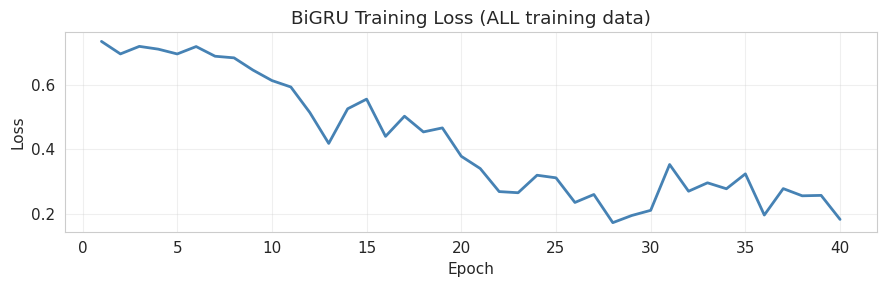

Extracting embeddings...
Embeddings: train=(284, 128), test=(72, 128)


In [54]:
# ============================================================
# CELL 9 — TRAIN BiGRU ON ALL TRAINING DATA → EXTRACT EMBEDDINGS
#
# BiGRU is trained on ALL training data (40 epochs, augmentation ON).
# After training, extract embeddings for train & test.
# The test set is NOT used for training - only for embedding extraction.
# ============================================================
print('Training BiGRU on ALL training data...')
print(f'Epochs: {BIGRU_EPOCHS} | LR: {BIGRU_LR} | Hidden: {BIGRU_HIDDEN} | Embed: {BIGRU_EMBED}')
print(f'Train size: {len(pids_tr)} | Augmentation: ON')
print('-'*55)

backbone = BiGRUAttention(
    in_channels=3, hidden=BIGRU_HIDDEN,
    n_layers=3, embed_dim=BIGRU_EMBED, dropout=BIGRU_DROPOUT
).to(DEVICE)

n_neg = (y_tr==0).sum(); n_pos = y_tr.sum()
pos_w = torch.FloatTensor([1.0, n_neg/n_pos]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=pos_w)

head = nn.Sequential(
    nn.LayerNorm(BIGRU_EMBED), nn.Dropout(0.4),
    nn.Linear(BIGRU_EMBED,64), nn.ReLU(),
    nn.Dropout(0.2), nn.Linear(64,2)
).to(DEVICE)

params = list(backbone.parameters()) + list(head.parameters())
opt    = torch.optim.AdamW(params, lr=BIGRU_LR, weight_decay=1e-4)
sch    = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2, eta_min=1e-5)

ds_all = ECGDataset(list(pids_tr), list(y_tr), signals_v123, augment=True)
dl_all = DataLoader(ds_all, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=0, pin_memory=(DEVICE.type=='cuda'))

best_loss  = float('inf')
best_state = None
loss_history = []

for epoch in range(BIGRU_EPOCHS):
    backbone.train(); head.train()
    epoch_loss = 0
    for x, y_b in dl_all:
        x, y_b = x.to(DEVICE), y_b.to(DEVICE)
        logits  = head(backbone(x))
        loss    = criterion(logits, y_b)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        epoch_loss += loss.item()
    sch.step()
    avg_loss = epoch_loss / len(dl_all)
    loss_history.append(avg_loss)
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = deepcopy(backbone.state_dict())
    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:3d}/{BIGRU_EPOCHS} | '
              f'Loss: {avg_loss:.4f} | '
              f'Best: {best_loss:.4f} | '
              f'LR: {opt.param_groups[0]["lr"]:.2e}')

backbone.load_state_dict(best_state)
print(f'\nBiGRU training complete. Best loss: {best_loss:.4f}')

# Plot training loss
fig, ax = plt.subplots(figsize=(9,3))
ax.plot(range(1, BIGRU_EPOCHS+1), loss_history, color='steelblue', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('BiGRU Training Loss (ALL training data)')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Extract embeddings
def extract_embeddings(backbone, pids, labels, sig_dict):
    backbone.eval()
    ds = ECGDataset(list(pids), list(labels), sig_dict, augment=False)
    dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    embs = []
    with torch.no_grad():
        for x, _ in dl:
            embs.append(backbone(x.to(DEVICE)).cpu().numpy())
    return np.vstack(embs)

print('Extracting embeddings...')
X_emb_tr = extract_embeddings(backbone, list(pids_tr), list(y_tr), signals_v123)
X_emb_te = extract_embeddings(backbone, list(pids_te), list(y_te), signals_v123)
print(f'Embeddings: train={X_emb_tr.shape}, test={X_emb_te.shape}')


## 10. Building the Three Feature Sets

After the traditional features and embeddings are available, they are organized into three experimental tracks:
1. **Traditional**
2. **DL_Embedding**
3. **Hybrid**

The goal of this stage is to make a fair comparison: does the best performance come from interpretable features, deep learning features, or their combination?

In [55]:
# ============================================================
# CELL 10 — ASSEMBLE FEATURE SETS
# A: Traditional only
# B: DL Embedding only
# C: Hybrid (Traditional + DL Embedding)
# ============================================================
FEATURE_SETS = {
    'Traditional':  (X_trad_tr, X_trad_te),
    'DL_Embedding': (X_emb_tr,  X_emb_te),
    'Hybrid':       (np.hstack([X_trad_tr, X_emb_tr]),
                     np.hstack([X_trad_te, X_emb_te])),
}

for name, (Xtr, Xte) in FEATURE_SETS.items():
    print(f'{name:15s}: train={Xtr.shape}, test={Xte.shape}')


Traditional    : train=(284, 153), test=(72, 153)
DL_Embedding   : train=(284, 128), test=(72, 128)
Hybrid         : train=(284, 281), test=(72, 281)


## 11. Candidate Models and Evaluation Metrics

This cell defines the list of classifiers to be tested on the three feature sets, while also preparing the evaluation functions.

Metric focus:
- **Recall** as the primary metric,
- **AUCPR** and **ROC-AUC** as comparison metrics,
- and **False Negative** counts because they are highly relevant clinically.

With this design, the experiment does not simply look for the model with the highest average score, but for the model that is **safest for screening**.

In [56]:
# ============================================================
# CELL 11 — MODEL DEFINITIONS + METRIC HELPERS
# ============================================================

def make_pipeline(model_name, y_tr_fold=None):
    """Pipeline: Imputer(median) → [Scaler] → Model."""
    steps = [('imputer', SimpleImputer(strategy='median'))]

    if model_name in ['LR','LR_C01','LR_C10','SVM_linear','SVM_rbf','MLP']:
        steps.append(('scaler', RobustScaler()))

    if y_tr_fold is not None:
        neg, pos = (y_tr_fold==0).sum(), (y_tr_fold==1).sum()
        spw = neg/pos if pos>0 else 1.0
    else:
        spw = 1.0

    models = {
        'LR': LogisticRegression(
            C=1.0, max_iter=2000, class_weight='balanced', random_state=SEED),
        'LR_C01': LogisticRegression(
            C=0.1, max_iter=2000, class_weight='balanced', random_state=SEED),
        'LR_C10': LogisticRegression(
            C=10.0, max_iter=2000, class_weight='balanced', random_state=SEED),
        'RF': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            min_samples_leaf=2, random_state=SEED, n_jobs=-1),
        'ExtraTrees': ExtraTreesClassifier(
            n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1),
        'XGB': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw,
            use_label_encoder=False, eval_metric='logloss',
            random_state=SEED, verbosity=0),
        'XGB_reg': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            min_child_weight=3, gamma=0.5,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.5, reg_lambda=2.0,
            scale_pos_weight=spw,
            use_label_encoder=False, eval_metric='aucpr',
            random_state=SEED, verbosity=0),
        'LGBM': lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            class_weight='balanced', random_state=SEED, verbose=-1),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(256,128,64), max_iter=300,
            early_stopping=True, validation_fraction=0.1,
            random_state=SEED),
        'SVM_rbf': SVC(
            kernel='rbf', C=1.0, gamma='scale',
            probability=True, class_weight='balanced', random_state=SEED),
    }

    clf = models[model_name]
    steps.append(('clf', clf))
    return Pipeline(steps)


MODEL_NAMES = ['LR','LR_C01','LR_C10','RF','ExtraTrees',
               'XGB','XGB_reg','LGBM','MLP','SVM_rbf']


def eval_metrics(y_true, y_pred, y_prob):
    """All metrics + confusion matrix counts."""
    cm = confusion_matrix(y_true, y_pred)
    tn,fp,fn,tp = cm.ravel() if cm.shape==(2,2) else (0,0,0,0)
    from sklearn.metrics import accuracy_score
    return {
        'roc_auc':   roc_auc_score(y_true, y_prob)  if len(np.unique(y_true))>1 else 0.5,
        'pr_auc':    average_precision_score(y_true, y_prob) if len(np.unique(y_true))>1 else 0.0,
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    }


n_combos = len(MODEL_NAMES) * len(FEATURE_SETS)
print(f'Models         : {MODEL_NAMES}')
print(f'Feature sets   : {list(FEATURE_SETS.keys())}')
print(f'Total combos   : {n_combos} × 5 folds = {n_combos*5} CV runs')
print(f'Manual threshold: {MANUAL_THRESHOLD} (rule-based)')
print('\nNote: Setiap fold → SMOTE + fit + full metrics (cukup lama, itu normal!)')


Models         : ['LR', 'LR_C01', 'LR_C10', 'RF', 'ExtraTrees', 'XGB', 'XGB_reg', 'LGBM', 'MLP', 'SVM_rbf']
Feature sets   : ['Traditional', 'DL_Embedding', 'Hybrid']
Total combos   : 30 × 5 folds = 150 CV runs
Manual threshold: 0.3 (rule-based)

Note: Setiap fold → SMOTE + fit + full metrics (cukup lama, itu normal!)


## 12. Brute-Force 5-Fold Cross-Validation on the Train Set

This stage tests all combinations of:
- **3 feature sets**
- × **10 models**
- = **30 model combinations**

Each fold uses only the train portion for fitting, while evaluation is performed on the validation fold.  
SMOTE and imputation are applied **inside each fold**, so no information leaks into the validation set.

The goals of this stage are:
- to systematically filter candidate models,
- to observe early performance patterns,
- and to understand which models look most promising **before** they are tested on the held-out test set.

In [57]:
# ============================================================
# CELL 12 — BRUTE FORCE: 5-FOLD CV ON TRAIN SET
#
# For each combination (feature set × model) × 5 folds:
#   - SMOTE per fold (no leakage)
#   - SimpleImputer per fold (no leakage)
#   - Evaluation: ROC-AUC, AUCPR, F1, Precision, Recall, FN count
#   - Print per model after all 5 folds are completed
#
# This is indeed slow - that is true! 30 combinations × 5 folds = 150 runs.
# ============================================================
print('='*65)
print('BRUTE FORCE: 5-Fold CV on Training Set')
print(f'Primary metric: RECALL (minimize False Negative!)')
print(f'Manual threshold (CV eval): {MANUAL_THRESHOLD}')
print('='*65)

skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)
cv_all = []

for feat_name, (X_tr_f, _) in FEATURE_SETS.items():
    print(f'\n{"="*55}')
    print(f'Feature Set: {feat_name}  (dim={X_tr_f.shape[1]})')
    print(f'{"="*55}')

    for model_name in MODEL_NAMES:
        fold_metrics = []

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_f, y_tr), 1):
            X_fold_tr  = X_tr_f[tr_idx];  y_fold_tr  = y_tr[tr_idx]
            X_fold_val = X_tr_f[val_idx]; y_fold_val = y_tr[val_idx]

            # SMOTE inside each fold - k_neighbors is safe relative to the minority count
            k_sm = min(5, max(1, y_fold_tr.sum()-1))
            try:
                X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_sm).fit_resample(
                    X_fold_tr, y_fold_tr)
            except:
                X_sm, y_sm = X_fold_tr, y_fold_tr

            try:
                pipe  = make_pipeline(model_name, y_sm)
                pipe.fit(X_sm, y_sm)
                ypr   = pipe.predict_proba(X_fold_val)[:,1]

                # Evaluate with default 0.5 AND the manual threshold
                ypd_def = (ypr>=0.5).astype(int)
                ypd_man = (ypr>=MANUAL_THRESHOLD).astype(int)

                m_def = eval_metrics(y_fold_val, ypd_def, ypr)
                m_man = eval_metrics(y_fold_val, ypd_man, ypr)

                m = {
                    'fold': fold, 'model': model_name, 'feature_set': feat_name,
                    # default-threshold metrics
                    **{f'def_{k}': v for k,v in m_def.items()},
                    # manual-threshold metrics
                    **{f'man_{k}': v for k,v in m_man.items()},
                }
                fold_metrics.append(m)

            except Exception as e:
                fold_metrics.append({
                    'fold':fold,'model':model_name,'feature_set':feat_name,
                    **{f'def_{k}':0 for k in ['roc_auc','pr_auc','f1','precision','recall','TP','FP','TN','FN']},
                    **{f'man_{k}':0 for k in ['roc_auc','pr_auc','f1','precision','recall','TP','FP','TN','FN']},
                    'error':str(e)
                })

        cv_all.extend(fold_metrics)

        # Print the fold summary after 5 folds
        fm_df = pd.DataFrame(fold_metrics)
        def s(col):
            return fm_df[col].mean() if col in fm_df else 0
        print(f'  {model_name:12s} | '
              f'AUC={s("def_roc_auc"):.4f}±{fm_df.get("def_roc_auc",pd.Series([0])).std():.3f} | '
              f'Recall(def)={s("def_recall"):.4f} | '
              f'Recall(thr={MANUAL_THRESHOLD})={s("man_recall"):.4f} | '
              f'Acc(man)={s("man_accuracy"):.4f} | '
              f'FN(man)={s("man_FN"):.1f}')

df_cv = pd.DataFrame(cv_all)
print(f'\nTotal CV records: {len(df_cv)} (= {len(MODEL_NAMES)} models × 3 feat × 5 folds)')


BRUTE FORCE: 5-Fold CV on Training Set
Primary metric: RECALL (minimize False Negative!)
Manual threshold (CV eval): 0.3

Feature Set: Traditional  (dim=153)
  LR           | AUC=0.8124±0.080 | Recall(def)=0.6182 | Recall(thr=0.3)=0.7091 | Acc(man)=0.7890 | FN(man)=3.2
  LR_C01       | AUC=0.8313±0.064 | Recall(def)=0.6909 | Recall(thr=0.3)=0.7455 | Acc(man)=0.7712 | FN(man)=2.8
  LR_C10       | AUC=0.7985±0.085 | Recall(def)=0.5818 | Recall(thr=0.3)=0.6182 | Acc(man)=0.7890 | FN(man)=4.2
  RF           | AUC=0.8771±0.037 | Recall(def)=0.6000 | Recall(thr=0.3)=0.8364 | Acc(man)=0.7782 | FN(man)=1.8
  ExtraTrees   | AUC=0.8773±0.049 | Recall(def)=0.5455 | Recall(thr=0.3)=0.8364 | Acc(man)=0.7993 | FN(man)=1.8
  XGB          | AUC=0.8998±0.036 | Recall(def)=0.6364 | Recall(thr=0.3)=0.7091 | Acc(man)=0.8627 | FN(man)=3.2
  XGB_reg      | AUC=0.8942±0.037 | Recall(def)=0.6364 | Recall(thr=0.3)=0.7455 | Acc(man)=0.8521 | FN(man)=2.8
  LGBM         | AUC=0.8833±0.035 | Recall(def)=0.6000 | R

## 13. Cross-Validation Results Summary

The output in this section shows the average cross-validation performance on the **train set**, not the final performance.

### Main interpretation of the results
- The **DL_Embedding** track dominates cross-validation.
- The best combination in CV is **DL_Embedding + ExtraTrees** with:
  - **Recall ≈ 0.927**
  - **AUCPR ≈ 0.960**
  - **ROC-AUC ≈ 0.982**
  - **average FN ≈ 0.8 per fold**
- The **Hybrid** track is also very strong in CV.
- The traditional models still lag behind in CV, with **Traditional + RF** and **Traditional + ExtraTrees** around **Recall ≈ 0.836**.

### What does this mean?
At this stage, the BiGRU embeddings appear very effective at capturing patterns that separate Brugada from Normal.  
However, **CV results should not yet be treated as the final winner**, because everything here is still measured on the train set. That is why the next stage, **evaluation on the held-out test set**, is the most important one.

=== CV SUMMARY — Manual thr=0.3 (ranked by Recall) ===
 cv_rank  feature_set      model  man_recall_mean  man_recall_std  man_pr_auc_mean  man_pr_auc_std  man_roc_auc_mean  man_roc_auc_std  man_accuracy_mean  man_FN_mean
       1 DL_Embedding ExtraTrees         0.927273        0.076060         0.959730        0.030139          0.981621         0.016291           0.936842          0.8
       2       Hybrid ExtraTrees         0.927273        0.076060         0.950510        0.041542          0.978656         0.016306           0.950877          0.8
       3 DL_Embedding     LR_C01         0.927273        0.076060         0.923301        0.068702          0.962055         0.041014           0.919236          0.8
       4 DL_Embedding         LR         0.927273        0.076060         0.923185        0.060876          0.959289         0.039934           0.926316          0.8
       5 DL_Embedding     LR_C10         0.927273        0.076060         0.920693        0.061950          0.95652

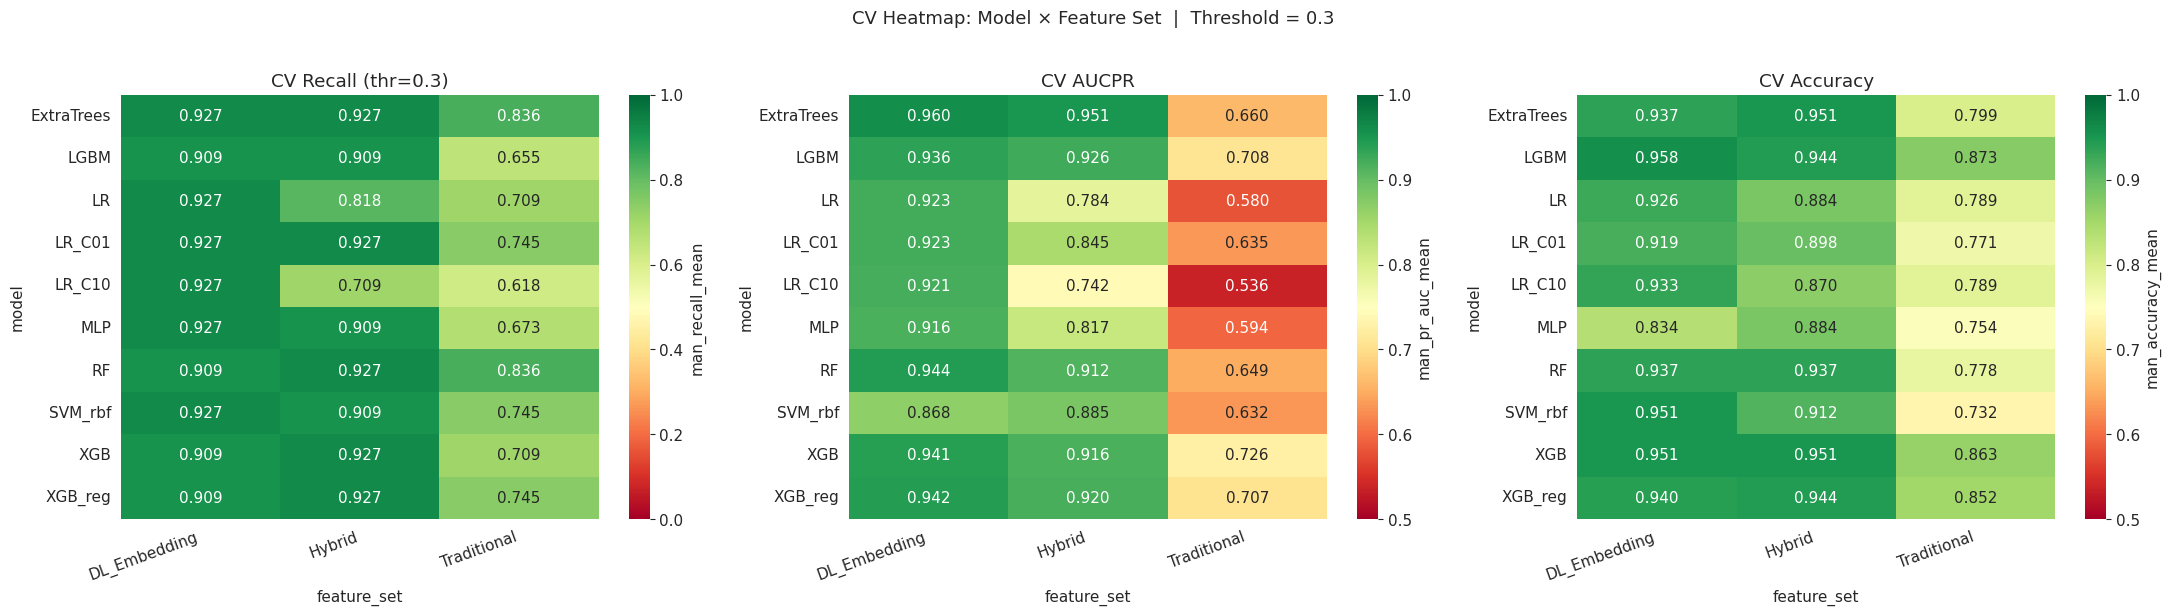

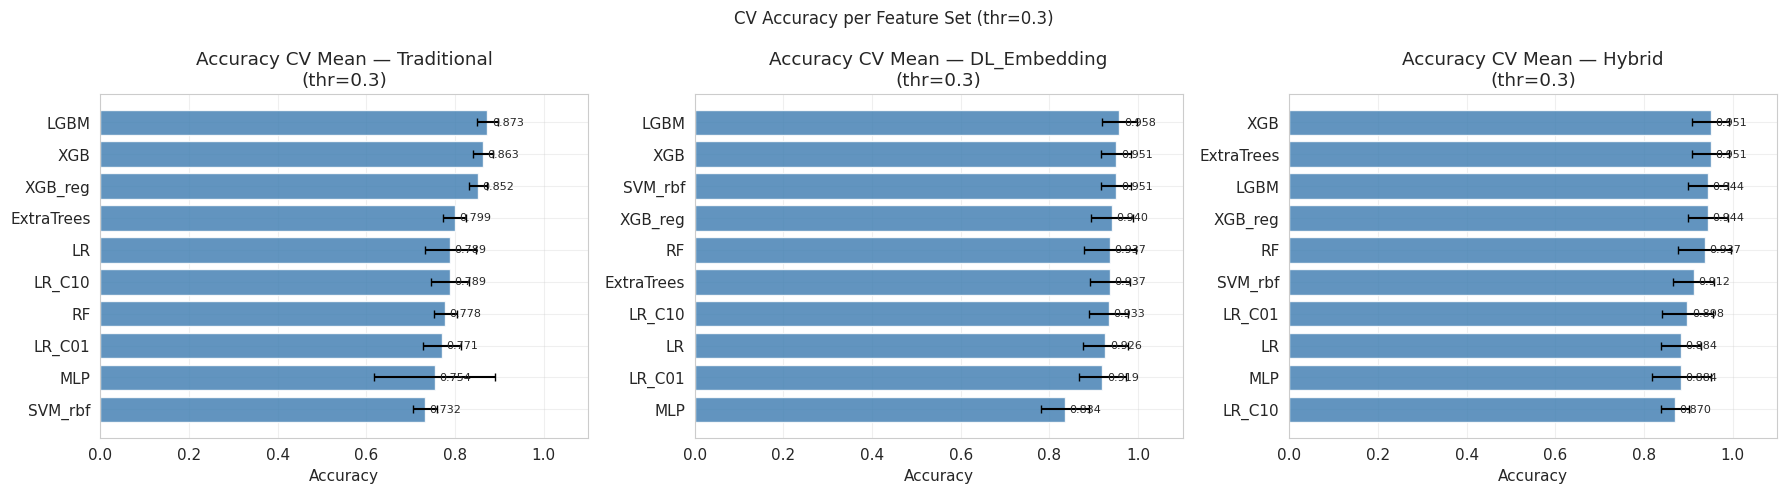

In [58]:
# ============================================================
# CELL 13 — CV SUMMARY & RANKING
# Ranking based on manual-threshold metrics
# ============================================================

# Aggregate per (feature_set, model)
agg_cols_def = ['def_roc_auc','def_pr_auc','def_accuracy','def_recall','def_FN']
agg_cols_man = ['man_roc_auc','man_pr_auc','man_accuracy','man_recall','man_FN']
all_agg = agg_cols_def + agg_cols_man

cv_summary = (
    df_cv.groupby(['feature_set','model'])[all_agg]
    .agg(['mean','std'])
    .reset_index()
)
cv_summary.columns = ['feature_set','model'] + [
    f'{m}_{s}' for m in all_agg for s in ['mean','std']
]

# Ranking: primary = recall at the manual threshold → secondary AUCPR → ROC-AUC
cv_summary = cv_summary.sort_values(
    ['man_recall_mean','man_pr_auc_mean','man_roc_auc_mean'],
    ascending=False
).reset_index(drop=True)
cv_summary.insert(0, 'cv_rank', range(1, len(cv_summary)+1))

print(f'=== CV SUMMARY — Manual thr={MANUAL_THRESHOLD} (ranked by Recall) ===')
show_cols = ['cv_rank','feature_set','model',
             'man_recall_mean','man_recall_std',
             'man_pr_auc_mean','man_pr_auc_std',
             'man_roc_auc_mean','man_roc_auc_std',
             'man_accuracy_mean','man_FN_mean']
print(cv_summary[show_cols].to_string(index=False))

# Heatmap: Recall, AUCPR, ROC-AUC (manual threshold)
fig, axes = plt.subplots(1, 3, figsize=(22,6))
for ax, metric, title, cmap in zip(
    axes,
    ['man_recall_mean','man_pr_auc_mean','man_accuracy_mean'],
    [f'Recall (thr={MANUAL_THRESHOLD})', 'AUCPR', 'Accuracy'],
    ['RdYlGn','RdYlGn','RdYlGn']
):
    pivot = cv_summary.pivot_table(index='model', columns='feature_set', values=metric)
    vmin = 0.0 if 'recall' in metric else 0.5
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                vmin=vmin, vmax=1.0, ax=ax,
                cbar_kws={'label': metric})
    ax.set_title(f'CV {title}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle(f'CV Heatmap: Model × Feature Set  |  Threshold = {MANUAL_THRESHOLD}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# F1 bar chart per model per feature set
fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax, fs_name in zip(axes, FEATURE_SETS.keys()):
    sub = cv_summary[cv_summary['feature_set']==fs_name].sort_values('man_accuracy_mean', ascending=True)
    bars = ax.barh(sub['model'], sub['man_accuracy_mean'], color='steelblue', alpha=0.85)
    ax.errorbar(sub['man_accuracy_mean'], sub['model'],
                xerr=sub.get('man_accuracy_std', pd.Series(np.zeros(len(sub)))),
                fmt='none', color='black', capsize=3)
    ax.set_title(f'Accuracy CV Mean — {fs_name}\n(thr={MANUAL_THRESHOLD})')
    ax.set_xlabel('Accuracy'); ax.set_xlim(0,1.1)
    for bar in bars:
        w = bar.get_width()
        ax.text(w+0.01, bar.get_y()+bar.get_height()/2, f'{w:.3f}',
                va='center', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'CV Accuracy per Feature Set (thr={MANUAL_THRESHOLD})', fontsize=12)
plt.tight_layout(); plt.show()


## 14. Retraining on the Full Train Set and Evaluation on the Held-Out Test Set

After the candidate models are filtered through cross-validation, each combination is retrained using the **entire train set**, then evaluated on the **held-out test set**.

This is the most important stage for answering the question:
> *Which model truly performs best when faced with patient data it has never seen before?*

In [59]:
# ============================================================
# CELL 14 — RETRAIN ON FULL TRAIN SET → EVAL ON HELD-OUT TEST
#
# No OOF threshold tuning.
# Threshold used: MANUAL_THRESHOLD = 0.15 (rule-based)
# Evaluation is done with TWO thresholds: default (0.5) and manual (0.15)
# ============================================================
print('='*65)
print(f'RETRAIN on FULL TRAIN → EVAL on HELD-OUT TEST')
print(f'Manual threshold: {MANUAL_THRESHOLD}  (rule-based, no tuning)')
print('='*65)

test_results   = []
trained_models = {}

for feat_name, (X_tr_f, X_te_f) in FEATURE_SETS.items():
    print(f'\n=== Feature Set: {feat_name} ===')

    for model_name in MODEL_NAMES:
        k_sm = min(5, max(1, y_tr.sum()-1))
        try:
            X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_sm).fit_resample(X_tr_f, y_tr)
        except:
            X_sm, y_sm = X_tr_f, y_tr

        try:
            pipe = make_pipeline(model_name, y_sm)
            pipe.fit(X_sm, y_sm)

            ypr_te = pipe.predict_proba(X_te_f)[:,1]

            ypd_def = (ypr_te>=0.5).astype(int)
            ypd_man = (ypr_te>=MANUAL_THRESHOLD).astype(int)

            m_def = eval_metrics(y_te, ypd_def, ypr_te)
            m_man = eval_metrics(y_te, ypd_man, ypr_te)

            row = {
                'feature_set': feat_name,
                'model':       model_name,
                'threshold_default': 0.5,
                'threshold_manual':  MANUAL_THRESHOLD,
            }
            for k,v in m_def.items(): row[f'def_{k}'] = v
            for k,v in m_man.items(): row[f'man_{k}'] = v
            test_results.append(row)
            trained_models[f'{feat_name}|{model_name}'] = pipe

            print(f'  {model_name:12s} | '
                  f'[thr=0.5 ] Rec={m_def["recall"]:.4f} Acc={m_def["accuracy"]:.4f} FN={m_def["FN"]} | '
                  f'[thr={MANUAL_THRESHOLD}] Rec={m_man["recall"]:.4f} Acc={m_man["accuracy"]:.4f} FN={m_man["FN"]} '
                  f'AUC={m_man["roc_auc"]:.4f}')

        except Exception as e:
            print(f'  {model_name}: ERROR {e}')

df_test = pd.DataFrame(test_results)
print(f'\nTest results: {len(df_test)} combinations')


RETRAIN on FULL TRAIN → EVAL on HELD-OUT TEST
Manual threshold: 0.3  (rule-based, no tuning)

=== Feature Set: Traditional ===
  LR           | [thr=0.5 ] Rec=0.5714 Acc=0.8333 FN=6 | [thr=0.3] Rec=0.5714 Acc=0.8194 FN=6 AUC=0.7562
  LR_C01       | [thr=0.5 ] Rec=0.5000 Acc=0.8333 FN=7 | [thr=0.3] Rec=0.5000 Acc=0.8056 FN=7 AUC=0.7660
  LR_C10       | [thr=0.5 ] Rec=0.5714 Acc=0.8194 FN=6 | [thr=0.3] Rec=0.5714 Acc=0.8056 FN=6 AUC=0.7599
  RF           | [thr=0.5 ] Rec=0.5000 Acc=0.8472 FN=7 | [thr=0.3] Rec=0.7143 Acc=0.7917 FN=4 AUC=0.8645
  ExtraTrees   | [thr=0.5 ] Rec=0.5000 Acc=0.8750 FN=7 | [thr=0.3] Rec=0.6429 Acc=0.8056 FN=5 AUC=0.8688
  XGB          | [thr=0.5 ] Rec=0.5000 Acc=0.8750 FN=7 | [thr=0.3] Rec=0.5714 Acc=0.8611 FN=6 AUC=0.8485
  XGB_reg      | [thr=0.5 ] Rec=0.5000 Acc=0.8889 FN=7 | [thr=0.3] Rec=0.5714 Acc=0.8472 FN=6 AUC=0.8411
  LGBM         | [thr=0.5 ] Rec=0.5000 Acc=0.8750 FN=7 | [thr=0.3] Rec=0.5000 Acc=0.8472 FN=7 AUC=0.8781
  MLP          | [thr=0.5 ] Rec=0

## 15. Final Ranking on the Held-Out Test Set

This section contains the **main result of the notebook** because the final ranking is computed from the held-out test set.

### Top-3 final models
1. **Traditional + RF**  
   - Recall = **0.714**
   - AUCPR = **0.725**
   - ROC-AUC = **0.865**
   - FN = **4**
2. **DL_Embedding + MLP**  
   - Recall = **0.643**
   - AUCPR = **0.749**
   - ROC-AUC = **0.893**
   - FN = **5**
3. **Traditional + ExtraTrees**  
   - Recall = **0.643**
   - AUCPR = **0.747**
   - ROC-AUC = **0.869**
   - FN = **5**

### Interpretation
These results show that the best model on unseen data is **not the model with the highest CV performance**, but **Traditional + Random Forest**.  
In other words, more interpretable and domain-informed features turn out to be **more stable when generalized to new patients**.

This is an important insight from the notebook:
- **Best in CV ≠ best in the final ranking**
- for relatively small medical datasets, simpler but clinically grounded models are often more resistant to overfitting than more complex deep learning representations.

FINAL RANKING — TEST SET  (threshold = 0.3, rule-based)
Objective: MINIMIZE FALSE NEGATIVE (fatal in clinical setting!)
 rank  feature_set      model  man_recall  man_pr_auc  man_roc_auc  man_precision  man_FN  man_TP  man_FP  def_recall  def_accuracy
    1  Traditional         RF    0.714286    0.725450     0.864532       0.476190       4      10      11    0.500000      0.847222
    2 DL_Embedding        MLP    0.642857    0.749211     0.892857       0.600000       5       9       6    0.500000      0.861111
    3  Traditional ExtraTrees    0.642857    0.747404     0.868842       0.500000       5       9       9    0.500000      0.875000
    4 DL_Embedding     LR_C01    0.642857    0.728284     0.850985       0.642857       5       9       5    0.571429      0.875000
    5       Hybrid         RF    0.642857    0.714219     0.800493       0.750000       5       9       3    0.500000      0.861111
    6  Traditional        XGB    0.571429    0.731417     0.848522       0.666667       

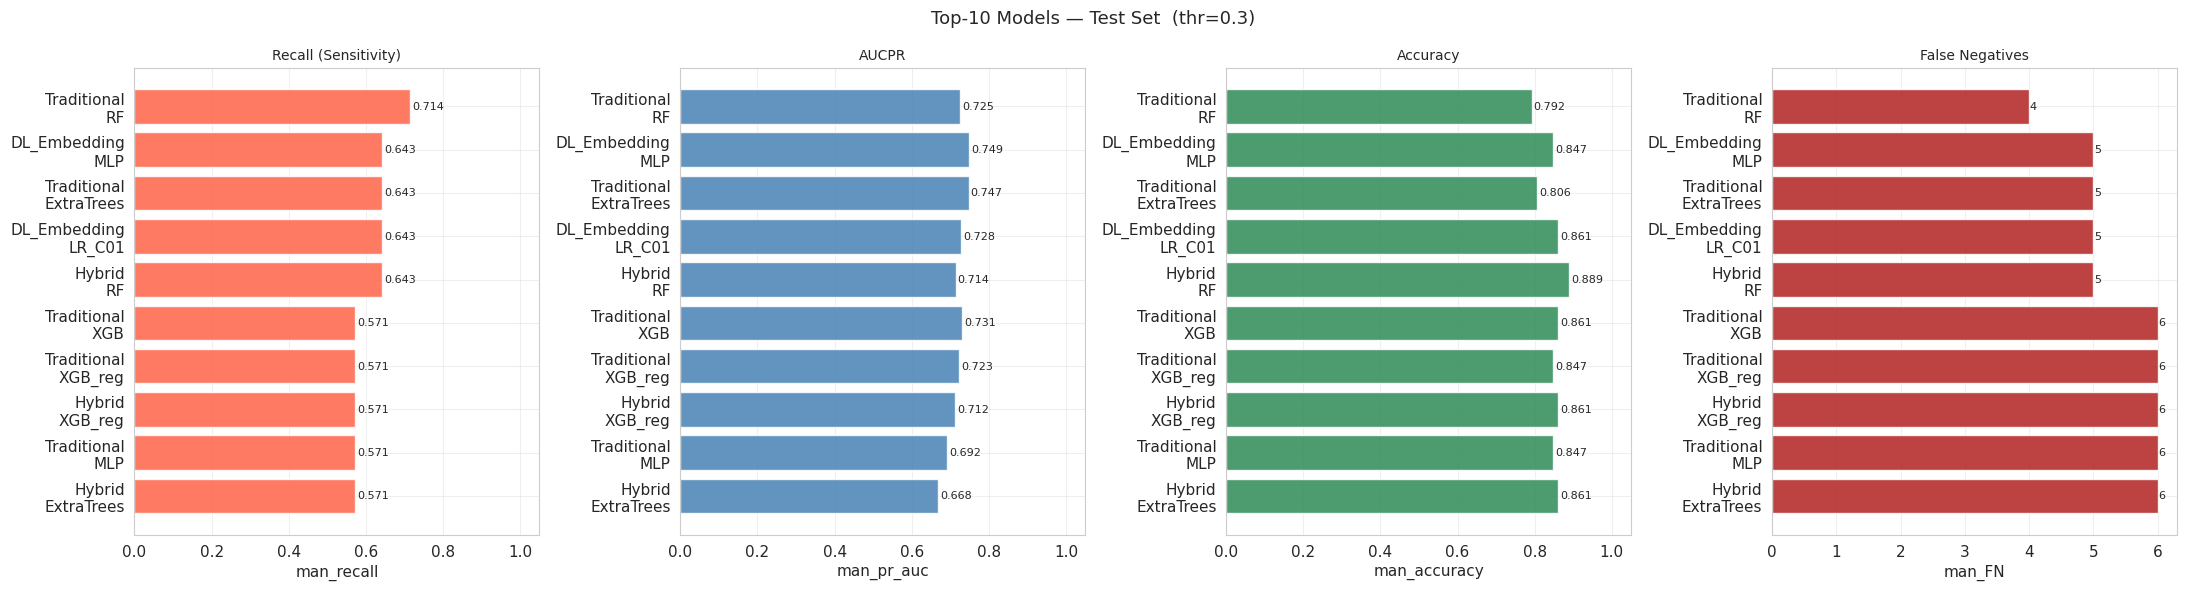

In [61]:
# ============================================================
# CELL 15 — FINAL RANKING DASHBOARD
# Rank: Recall(manual thr) → AUCPR → ROC-AUC
# ============================================================

df_rank = df_test.sort_values(
    ['man_recall','man_pr_auc','man_roc_auc'],
    ascending=False
).reset_index(drop=True)
df_rank.insert(0, 'rank', range(1, len(df_rank)+1))

print('='*75)
print(f'FINAL RANKING — TEST SET  (threshold = {MANUAL_THRESHOLD}, rule-based)')
print('Objective: MINIMIZE FALSE NEGATIVE (fatal in clinical setting!)')
print('='*75)

show_cols = ['rank','feature_set','model',
             'man_recall','man_pr_auc','man_roc_auc','man_precision',
             'man_FN','man_TP','man_FP',
             'def_recall','def_accuracy']
print(df_rank[show_cols].to_string(index=False))

# Top-10 bar chart
top10 = df_rank.head(10).copy()
top10['label'] = top10['feature_set'] + '\n' + top10['model']

fig, axes = plt.subplots(1, 4, figsize=(22,6))
fig.suptitle(f'Top-10 Models — Test Set  (thr={MANUAL_THRESHOLD})', fontsize=13)

for ax, col, title, color in zip(
    axes,
    ['man_recall','man_pr_auc','man_accuracy','man_FN'],
    ['Recall (Sensitivity)','AUCPR','Accuracy','False Negatives'],
    ['tomato','steelblue','seagreen','firebrick']
):
    vals = top10[col].values
    bars = ax.barh(top10['label'].values[::-1], vals[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
    for bar in bars:
        w = bar.get_width()
        ax.text(w+0.005, bar.get_y()+bar.get_height()/2,
                f'{w:.3f}' if col!='man_FN' else f'{int(w)}',
                va='center', fontsize=8)
    ax.grid(True, alpha=0.3)
    if col != 'man_FN': ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()


## 16. Visual Diagnostics for the Top Models

This cell visualizes:
- confusion matrices,
- ROC curves,
- and F1 scores  
for several top-performing models.

The goal is to help the reader inspect model performance **beyond a single number**.  
For example, two models may have similar ROC-AUC values but very different FP and FN trade-offs once a threshold is applied.

When reading these visuals, the main focus remains:
- how many Brugada cases are captured,
- and how many Brugada patients are still missed.

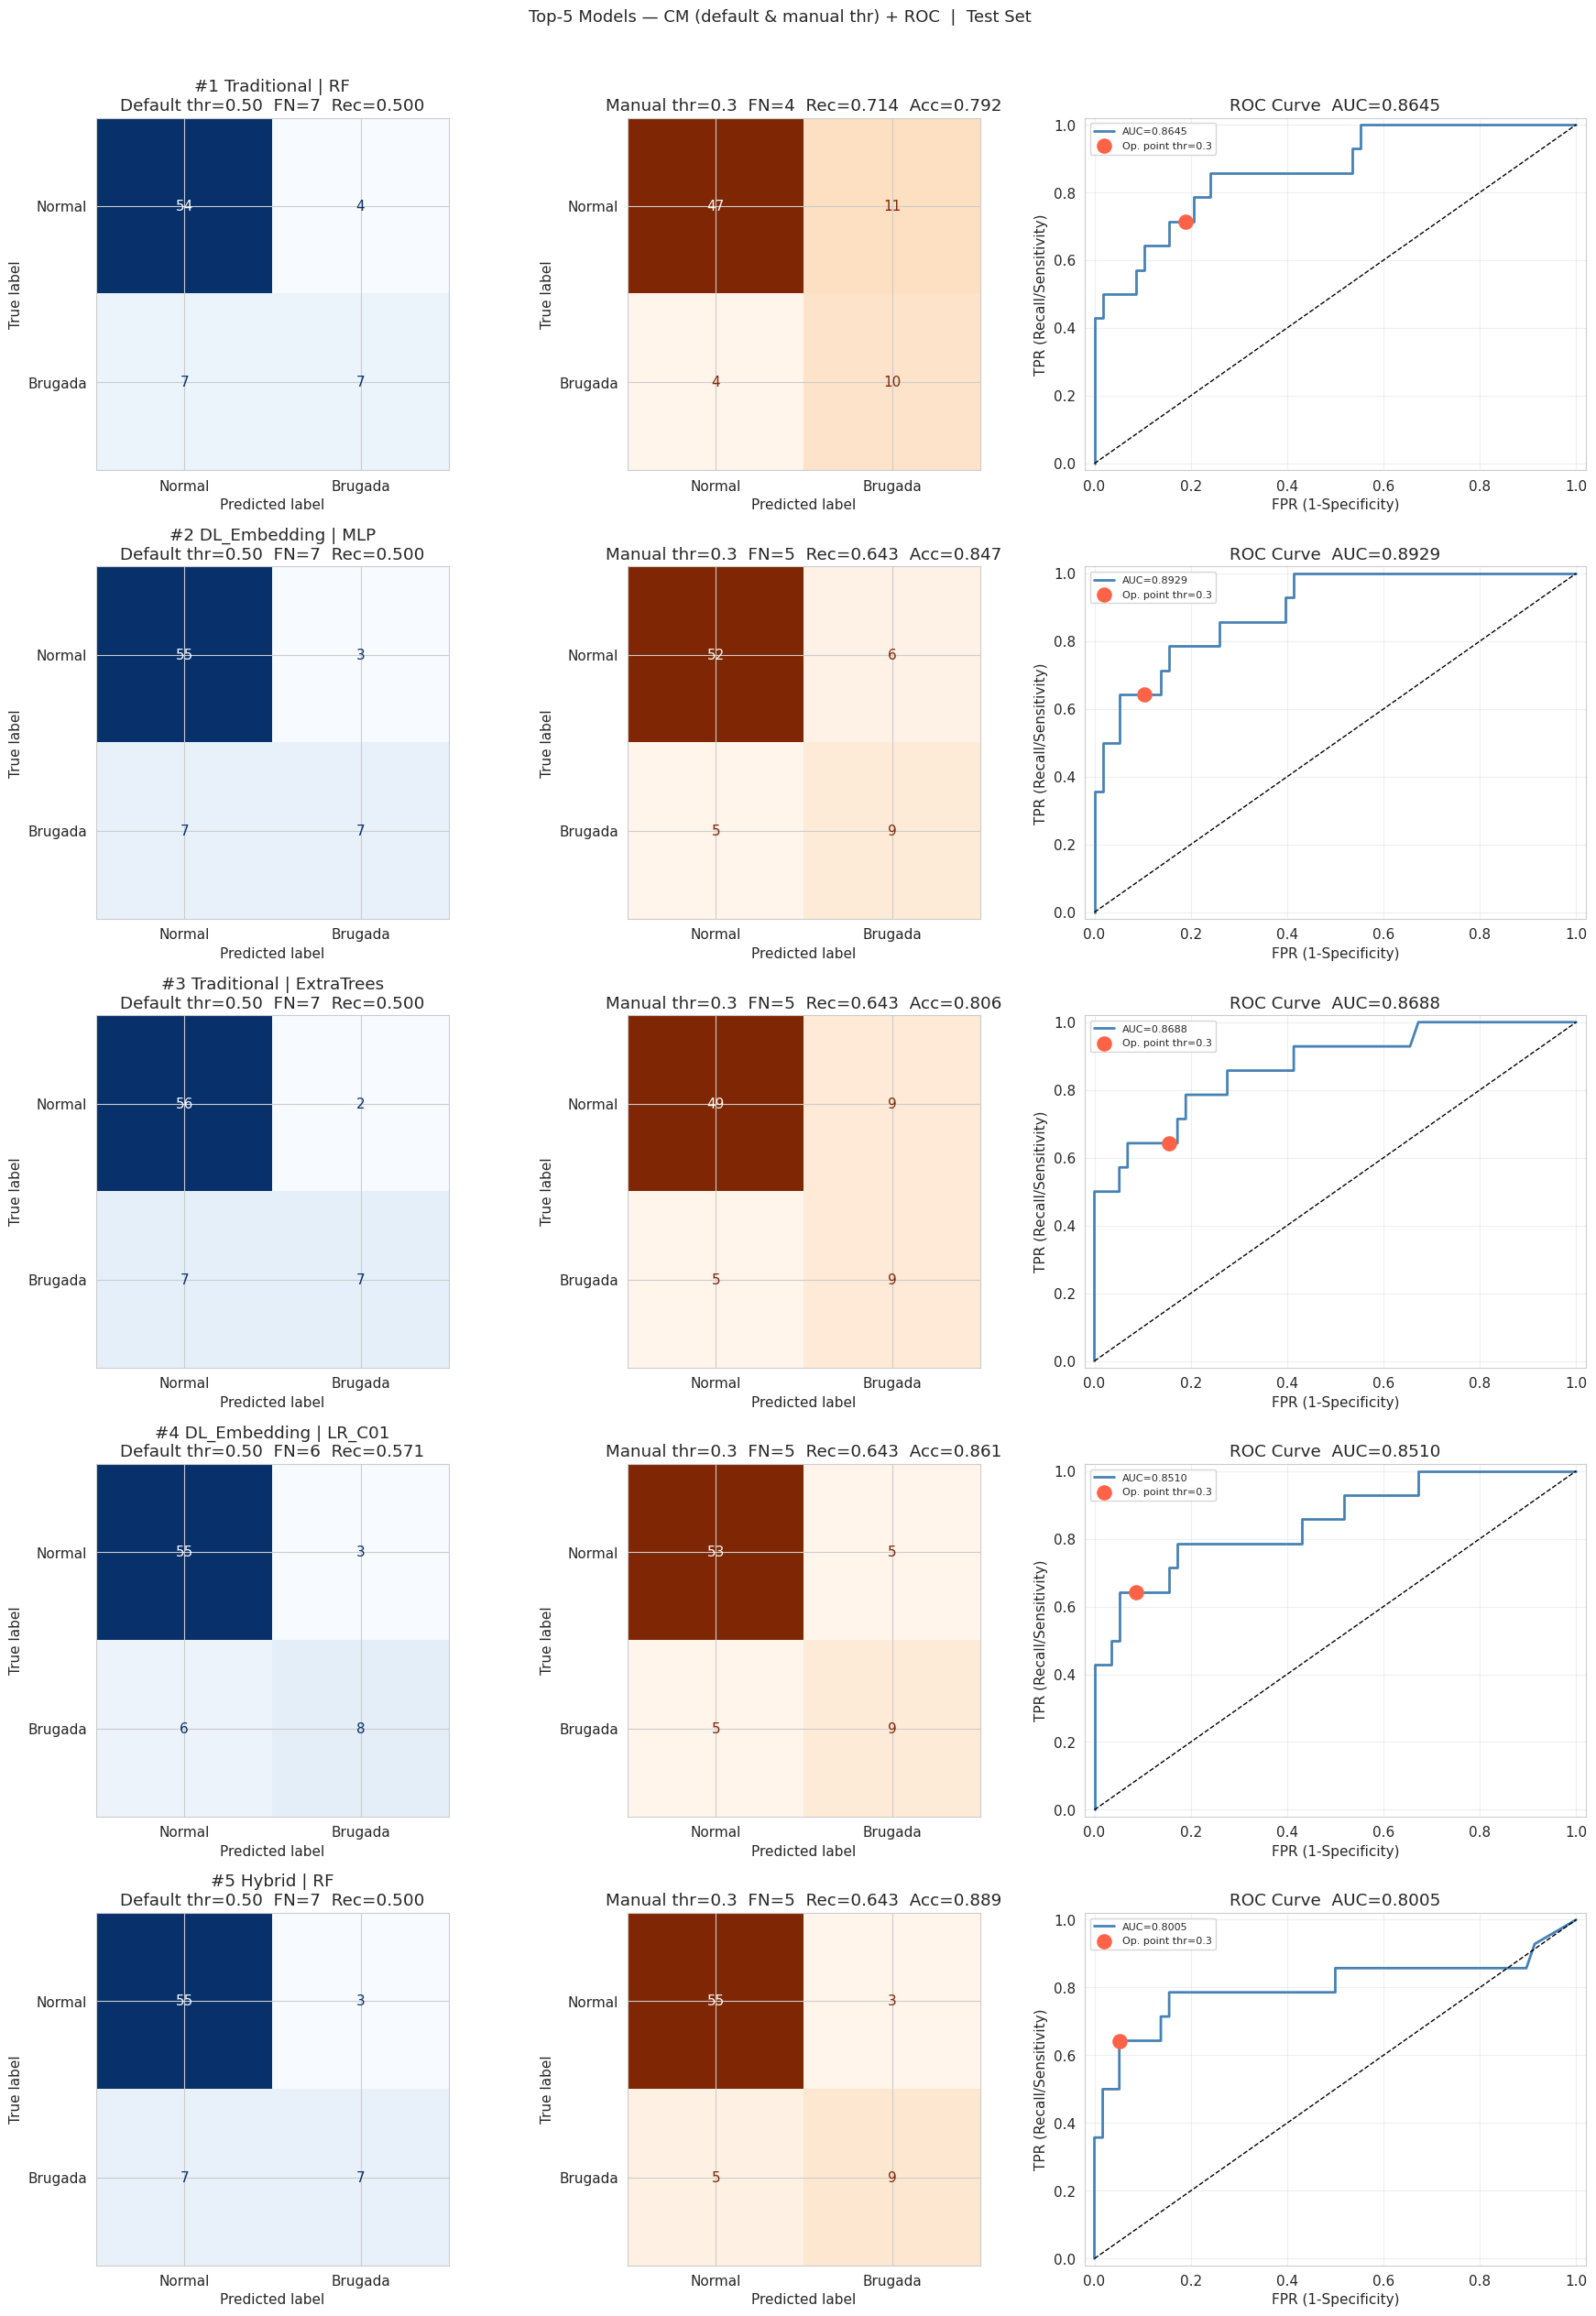

In [62]:
# ============================================================
# CELL 16 — CONFUSION MATRIX + ROC CURVE + F1 BAR — TOP-5
#
# For each top-5 model:
#   Col 0: Confusion Matrix (default thr=0.5)
#   Col 1: Confusion Matrix (manual thr=MANUAL_THRESHOLD)
#   Col 2: ROC curve with the operating point marked
# ============================================================
TOP_N = 5
top_rows = df_rank.head(TOP_N)[['feature_set','model']].values.tolist()

fig, axes = plt.subplots(TOP_N, 3, figsize=(18, 5*TOP_N))
fig.suptitle(
    f'Top-{TOP_N} Models — CM (default & manual thr) + ROC  |  Test Set',
    fontsize=13, y=1.01
)

for row_i, (feat_name, model_name) in enumerate(top_rows):
    key  = f'{feat_name}|{model_name}'
    pipe = trained_models[key]
    X_te_f = FEATURE_SETS[feat_name][1]

    ypr = pipe.predict_proba(X_te_f)[:,1]
    ypd_def = (ypr>=0.5).astype(int)
    ypd_man = (ypr>=MANUAL_THRESHOLD).astype(int)

    rk = df_rank[df_rank['rank']==row_i+1].iloc[0]
    title_base = (f'#{row_i+1} {feat_name} | {model_name}')

    # -- Col 0: default CM --
    ax0 = axes[row_i, 0]
    cm0 = confusion_matrix(y_te, ypd_def)
    ConfusionMatrixDisplay(cm0, display_labels=['Normal','Brugada']).plot(
        ax=ax0, colorbar=False, cmap='Blues')
    ax0.set_title(f'{title_base}\nDefault thr=0.50  FN={rk["def_FN"]}  Rec={rk["def_recall"]:.3f}')

    # -- Col 1: manual-threshold CM --
    ax1 = axes[row_i, 1]
    cm1 = confusion_matrix(y_te, ypd_man)
    ConfusionMatrixDisplay(cm1, display_labels=['Normal','Brugada']).plot(
        ax=ax1, colorbar=False, cmap='Oranges')
    ax1.set_title(f'Manual thr={MANUAL_THRESHOLD}  FN={rk["man_FN"]}  Rec={rk["man_recall"]:.3f}  Acc={rk["man_accuracy"]:.3f}')

    # -- Col 2: ROC curve --
    ax2 = axes[row_i, 2]
    fpr_c, tpr_c, _ = roc_curve(y_te, ypr)
    roc_val = auc(fpr_c, tpr_c)
    ax2.plot(fpr_c, tpr_c, lw=2, color='steelblue', label=f'AUC={roc_val:.4f}')
    ax2.plot([0,1],[0,1],'k--',lw=1)

    # Operating point at the manual threshold
    tn_m,fp_m,fn_m,tp_m = cm1.ravel() if cm1.shape==(2,2) else (0,0,0,0)
    rec_op = tp_m/(tp_m+fn_m+1e-8)
    spec_op = tn_m/(tn_m+fp_m+1e-8)
    fpr_op  = 1 - spec_op
    ax2.scatter([fpr_op],[rec_op], c='tomato', s=120, zorder=5,
                label=f'Op. point thr={MANUAL_THRESHOLD}')
    ax2.set_xlabel('FPR (1-Specificity)')
    ax2.set_ylabel('TPR (Recall/Sensitivity)')
    ax2.set_title(f'ROC Curve  AUC={roc_val:.4f}')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    ax2.set_xlim([-0.02,1.02]); ax2.set_ylim([-0.02,1.02])

plt.tight_layout()
plt.show()


## 17. F1 Analysis Across Thresholds

This section evaluates how threshold changes affect the balance between precision and recall.

Its goals are:
- to show that threshold is not merely a technical parameter,
- but a design decision that changes the clinical trade-off.

In the Brugada screening context, a lower threshold tends to increase FP, but it can reduce FN.  
Because the consequences of FN are much more serious, threshold **0.30** is chosen as the safer compromise.

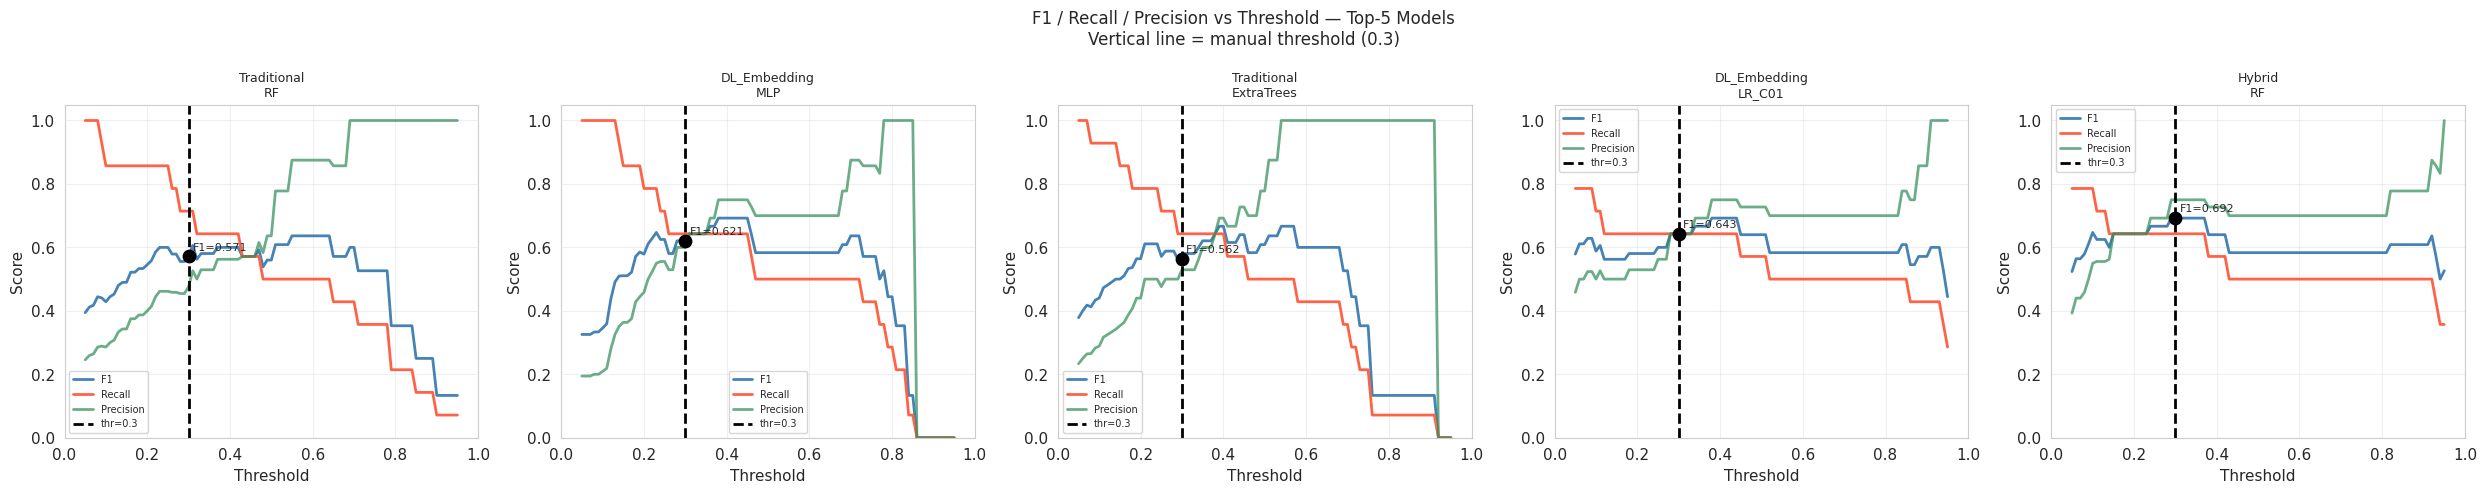

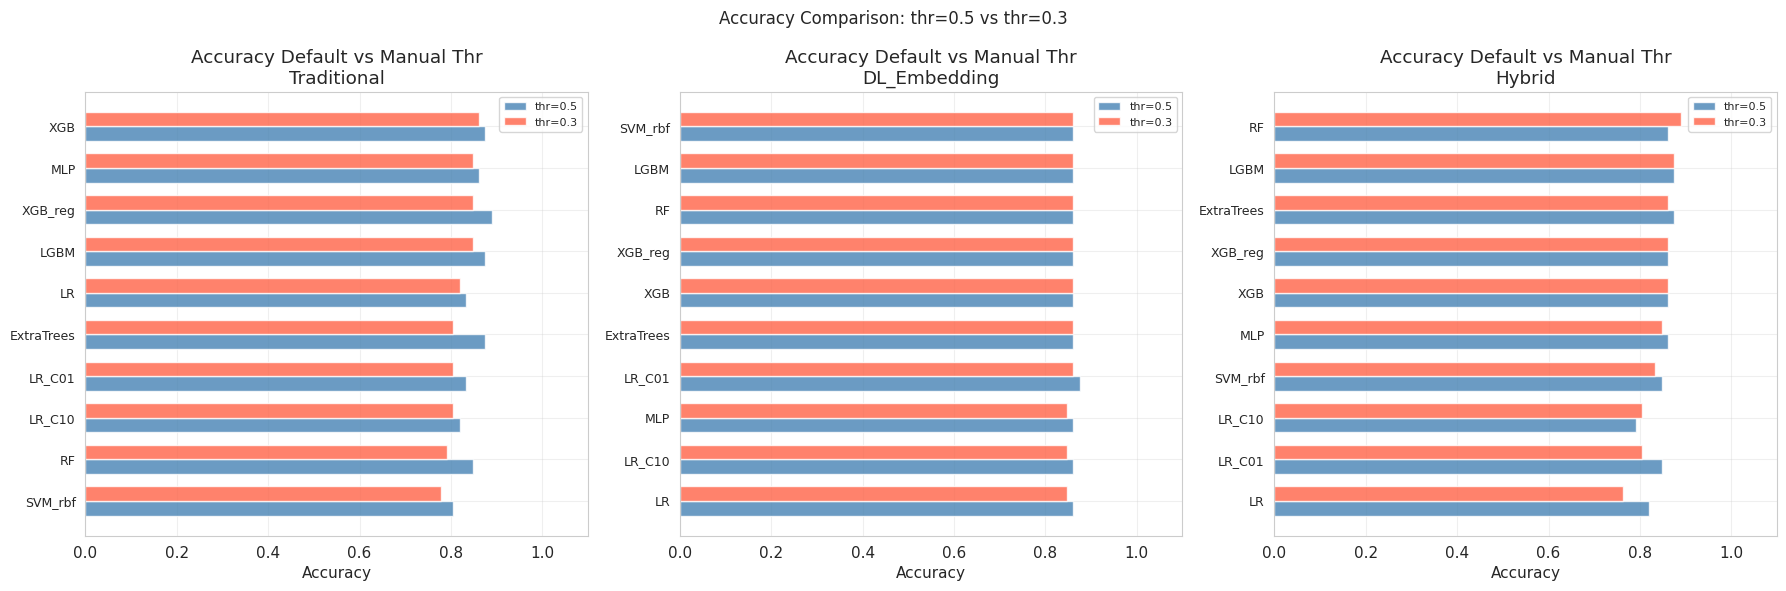

In [63]:
# ============================================================
# CELL 17 — F1 SCORE vs THRESHOLD CURVE (Top-5 models)
#
# Visualize how F1, Recall, and Precision change with the threshold.
# The manual threshold (0.15) is marked with a vertical line.
# ============================================================
top5_rows = df_rank.head(5)[['feature_set','model']].values.tolist()

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(
    f'F1 / Recall / Precision vs Threshold — Top-5 Models\n'
    f'Vertical line = manual threshold ({MANUAL_THRESHOLD})',
    fontsize=12
)

thresholds = np.arange(0.05, 0.96, 0.01)

for ax, (feat_name, model_name) in zip(axes, top5_rows):
    key  = f'{feat_name}|{model_name}'
    pipe = trained_models[key]
    X_te_f = FEATURE_SETS[feat_name][1]

    ypr = pipe.predict_proba(X_te_f)[:,1]

    f1s, recs, precs = [], [], []
    for t in thresholds:
        ypd_t = (ypr>=t).astype(int)
        f1s.append(f1_score(y_te, ypd_t, zero_division=0))
        recs.append(recall_score(y_te, ypd_t, zero_division=0))
        precs.append(precision_score(y_te, ypd_t, zero_division=0))

    ax.plot(thresholds, f1s,   lw=2, color='steelblue', label='F1')
    ax.plot(thresholds, recs,  lw=2, color='tomato',    label='Recall')
    ax.plot(thresholds, precs, lw=2, color='seagreen',  label='Precision', alpha=0.7)

    # Manual threshold line
    ax.axvline(MANUAL_THRESHOLD, color='black', lw=2, linestyle='--',
               label=f'thr={MANUAL_THRESHOLD}')

    # Mark F1 at manual threshold
    man_f1_val = f1_score(y_te, (ypr>=MANUAL_THRESHOLD).astype(int), zero_division=0)
    ax.scatter([MANUAL_THRESHOLD],[man_f1_val], c='black', s=80, zorder=5)
    ax.text(MANUAL_THRESHOLD+0.01, man_f1_val+0.02, f'F1={man_f1_val:.3f}', fontsize=8)

    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{feat_name}\n{model_name}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Accuracy bar chart: default vs manual, all combinations
fig, axes = plt.subplots(1,3, figsize=(18,6))
for ax, fs_name in zip(axes, FEATURE_SETS.keys()):
    sub = df_test[df_test['feature_set']==fs_name].sort_values('man_accuracy', ascending=True)
    x   = np.arange(len(sub))
    w   = 0.35
    ax.barh(x - w/2, sub['def_accuracy'].values, height=w, color='steelblue', alpha=0.8, label='thr=0.5')
    ax.barh(x + w/2, sub['man_accuracy'].values, height=w, color='tomato',    alpha=0.8, label=f'thr={MANUAL_THRESHOLD}')
    ax.set_yticks(x); ax.set_yticklabels(sub['model'].values, fontsize=9)
    ax.set_xlabel('Accuracy'); ax.set_xlim(0,1.1)
    ax.set_title(f'Accuracy Default vs Manual Thr\n{fs_name}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'Accuracy Comparison: thr=0.5 vs thr={MANUAL_THRESHOLD}', fontsize=12)
plt.tight_layout(); plt.show()


## 18. CV vs Test Comparison: Do the Models Truly Generalize?

This section compares train/CV performance with held-out test performance to measure the **generalization gap**.

### Main interpretation
- **Traditional + RF** has a relatively small recall gap:  
  **0.836 → 0.714** (gap ≈ **0.12**)
- In contrast, some DL models show a larger drop, for example:
  - **DL_Embedding + MLP**: **0.927 → 0.643** (gap ≈ **0.28**)
  - **DL_Embedding + LR_C01**: **0.927 → 0.643** (gap ≈ **0.28**)

### Practical meaning
Deep learning models appear very strong in train/CV, but part of that performance does not hold up when tested on new data.  
Meanwhile, **Traditional + RF** may not be the most glamorous model in CV, but it is more trustworthy for deployment because its generalization gap is smaller.

CV vs Test Comparison (thr=0.3, top-10 by test_recall):
 feature_set      model  cv_recall  cv_aucpr   cv_auc  cv_FN  test_recall  test_aucpr  test_auc  test_FN  recall_gap  auc_gap
 Traditional         RF   0.836364  0.649088 0.877093    1.8     0.714286    0.725450  0.864532        4    0.122078 0.012561
DL_Embedding     LR_C01   0.927273  0.923301 0.962055    0.8     0.642857    0.728284  0.850985        5    0.284416 0.111070
      Hybrid         RF   0.927273  0.912287 0.963241    0.8     0.642857    0.714219  0.800493        5    0.284416 0.162748
DL_Embedding        MLP   0.927273  0.916297 0.962451    0.8     0.642857    0.749211  0.892857        5    0.284416 0.069593
 Traditional ExtraTrees   0.836364  0.660271 0.877347    1.8     0.642857    0.747404  0.868842        5    0.193506 0.008505
      Hybrid ExtraTrees   0.927273  0.950510 0.978656    0.8     0.571429    0.668305  0.807266        6    0.355844 0.171390
 Traditional    SVM_rbf   0.745455  0.631764 0.835687    2.8  

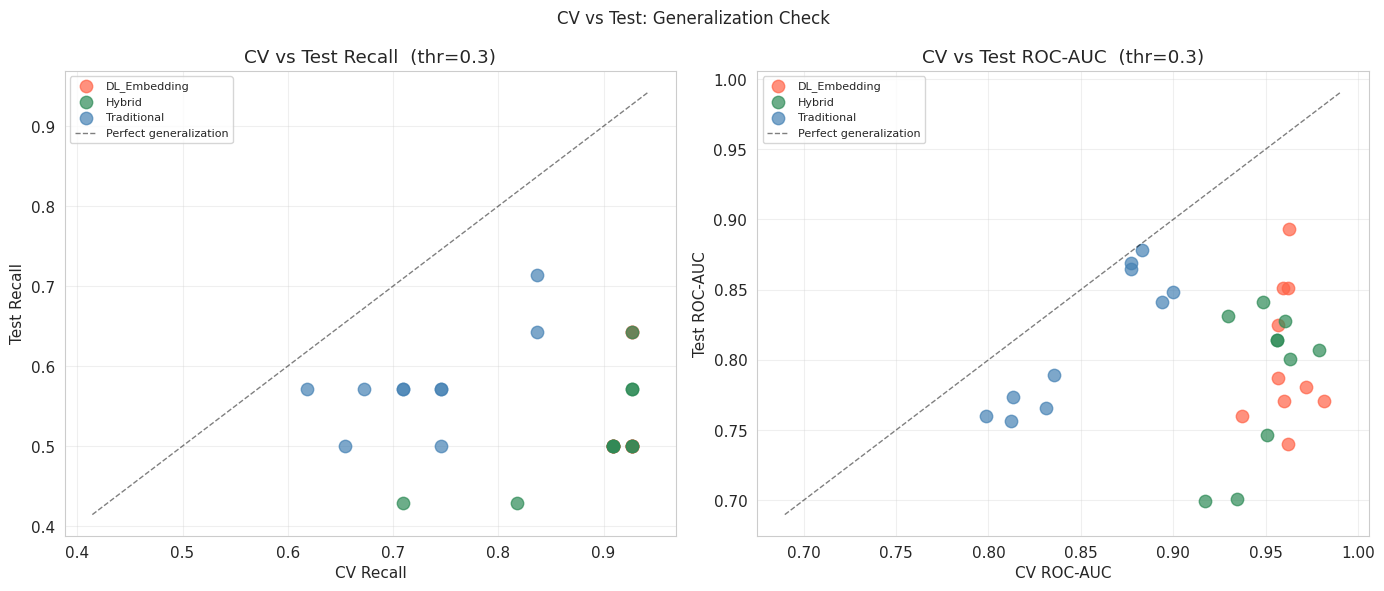

In [64]:
# ============================================================
# CELL 18 — CV vs TEST COMPARISON (generalization check)
# ============================================================
cv_merge = cv_summary[['feature_set','model',
                        'man_recall_mean','man_pr_auc_mean',
                        'man_roc_auc_mean','man_FN_mean']].copy()
cv_merge.columns = ['feature_set','model',
                    'cv_recall','cv_aucpr','cv_auc','cv_FN']

test_merge = df_test[['feature_set','model',
                       'man_recall','man_pr_auc','man_roc_auc','man_FN']].copy()
test_merge.columns = ['feature_set','model',
                      'test_recall','test_aucpr','test_auc','test_FN']

compare = cv_merge.merge(test_merge, on=['feature_set','model'])
compare['recall_gap'] = compare['cv_recall'] - compare['test_recall']
compare['auc_gap']    = compare['cv_auc']    - compare['test_auc']
compare = compare.sort_values('test_recall', ascending=False)

print(f'CV vs Test Comparison (thr={MANUAL_THRESHOLD}, top-10 by test_recall):')
print(compare.head(10).to_string(index=False))

colors = {'Traditional':'steelblue','DL_Embedding':'tomato','Hybrid':'seagreen'}

fig, axes = plt.subplots(1,2, figsize=(14,6))
for fs_name, grp in compare.groupby('feature_set'):
    axes[0].scatter(grp['cv_recall'], grp['test_recall'],
                    c=colors.get(fs_name,'gray'), label=fs_name, alpha=0.7, s=80)
    axes[1].scatter(grp['cv_auc'],    grp['test_auc'],
                    c=colors.get(fs_name,'gray'), label=fs_name, alpha=0.7, s=80)

for ax, metric in zip(axes, ['Recall','ROC-AUC']):
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo,hi],[lo,hi],'k--',lw=1,alpha=0.5,label='Perfect generalization')
    ax.set_xlabel(f'CV {metric}'); ax.set_ylabel(f'Test {metric}')
    ax.set_title(f'CV vs Test {metric}  (thr={MANUAL_THRESHOLD})')
    ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

plt.suptitle('CV vs Test: Generalization Check', fontsize=12)
plt.tight_layout(); plt.show()


## 19. Feature Importance in the Best Model

This analysis is performed on the final best model, **Traditional + RF**.

### What is visible?
The top features are dominated by:
- **V1 and V2**
- **ST segment** amplitude/area
- ST slope
- **T-wave** polarity and peak

### Interpretation
This is a very positive sign from a clinical standpoint.  
It means the best model is not learning from random noise, but from components that are genuinely relevant to Brugada patterns, especially changes in the ST segment, J-point, and T-wave in leads V1-V2.

In other words, the model is not only “successful”, but also **physiologically meaningful**.

Feature importance for: Traditional|RF


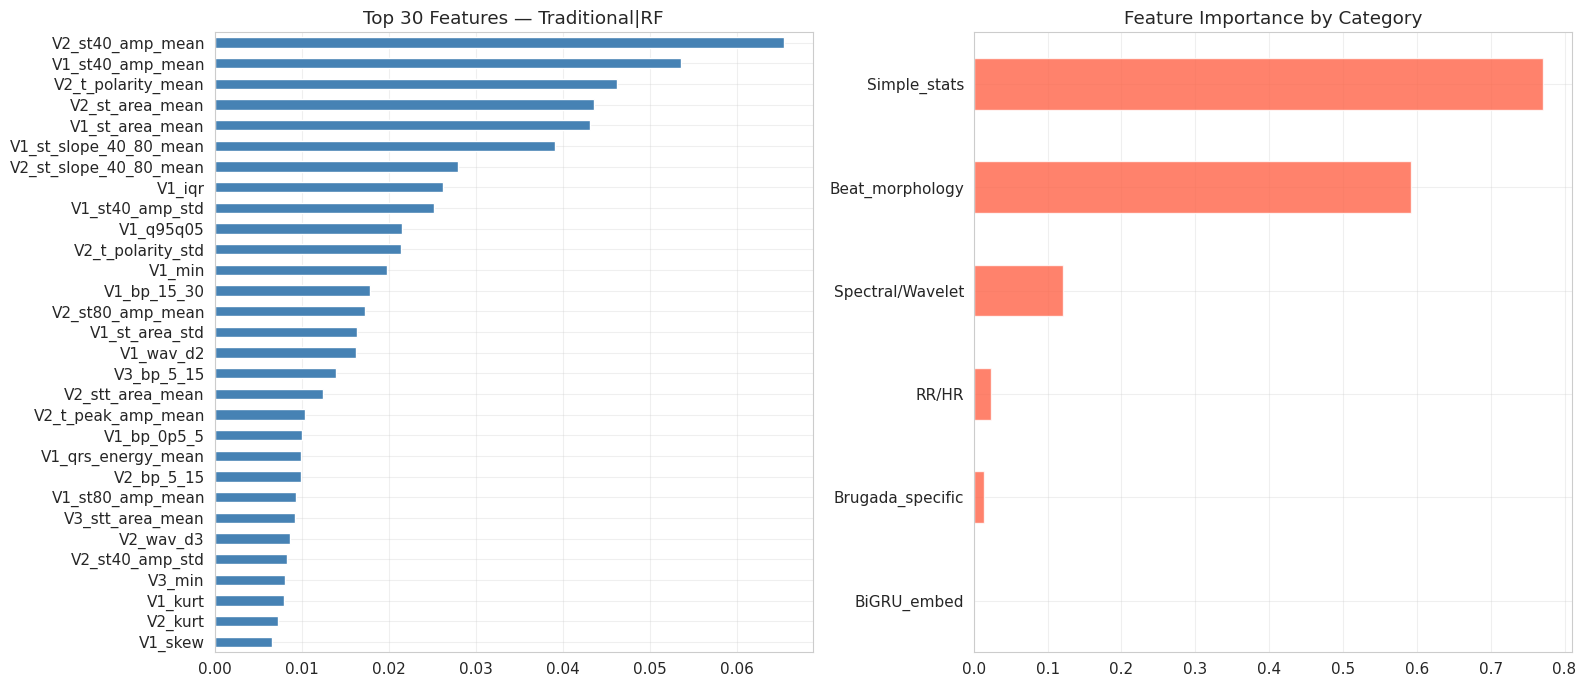


Top 20 features:
V2_st40_amp_mean          0.065469
V1_st40_amp_mean          0.053591
V2_t_polarity_mean        0.046275
V2_st_area_mean           0.043648
V1_st_area_mean           0.043163
V1_st_slope_40_80_mean    0.039084
V2_st_slope_40_80_mean    0.027922
V1_iqr                    0.026238
V1_st40_amp_std           0.025201
V1_q95q05                 0.021504
V2_t_polarity_std         0.021437
V1_min                    0.019776
V1_bp_15_30               0.017906
V2_st80_amp_mean          0.017325
V1_st_area_std            0.016320
V1_wav_d2                 0.016234
V3_bp_5_15                0.013908
V2_stt_area_mean          0.012419
V2_t_peak_amp_mean        0.010438
V1_bp_0p5_5               0.010071


In [65]:
# ============================================================
# CELL 19 — FEATURE IMPORTANCE (Best model)
# ============================================================
best_feat  = df_rank.iloc[0]['feature_set']
best_model = df_rank.iloc[0]['model']
best_key   = f'{best_feat}|{best_model}'

print(f'Feature importance for: {best_key}')
pipe_best = trained_models[best_key]
clf_best  = pipe_best.named_steps['clf']

if best_feat == 'Traditional':
    feat_names = list(df_trad_all.columns)
elif best_feat == 'DL_Embedding':
    feat_names = [f'bigru_{i}' for i in range(BIGRU_EMBED)]
else:
    feat_names = list(df_trad_all.columns) + [f'bigru_{i}' for i in range(BIGRU_EMBED)]

if hasattr(clf_best, 'feature_importances_'):
    imp = pd.Series(clf_best.feature_importances_, index=feat_names[:len(clf_best.feature_importances_)])
    imp = imp.sort_values(ascending=False)

    fig, axes = plt.subplots(1,2, figsize=(16,7))

    imp.head(30).plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'Top 30 Features — {best_key}')
    axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3)

    cats = {
        'BiGRU_embed':      imp[[c for c in imp.index if c.startswith('bigru')]].sum(),
        'Beat_morphology':  imp[[c for c in imp.index if any(k in c for k in ['j_amp','st','stt','r_amp','qrs'])]].sum(),
        'Spectral/Wavelet': imp[[c for c in imp.index if any(k in c for k in ['bp_','wav_'])]].sum(),
        'RR/HR':            imp[[c for c in imp.index if any(k in c for k in ['rr_','hr_'])]].sum(),
        'Simple_stats':     imp[[c for c in imp.index if any(k in c for k in ['mean','std','min','max','rms','iqr'])]].sum(),
        'Brugada_specific': imp[[c for c in imp.index if 'brugada' in c]].sum(),
    }
    pd.Series(cats).sort_values().plot(kind='barh', ax=axes[1], color='tomato', alpha=0.8)
    axes[1].set_title('Feature Importance by Category')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    print('\nTop 20 features:')
    print(imp.head(20).to_string())
elif hasattr(clf_best, 'coef_'):
    imp = pd.Series(np.abs(clf_best.coef_[0]), index=feat_names[:len(clf_best.coef_[0])])
    imp = imp.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12,7))
    imp.head(30).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 30 |Coefficients| — {best_key}')
    ax.invert_yaxis(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print('\nTop 20 features (|coef|):')
    print(imp.head(20).to_string())
else:
    print(f'Model {best_model} does not support feature_importances_ atau coef_')


## 20. Blind Test on Patients with Uncertain Labels

Patients with **label 2** are not used in supervised training, and are then analyzed separately using an ensemble of the top-3 final models.

### Main results
- Out of **7 uncertain patients**:
  - **5 patients** receive high probabilities and are flagged at both threshold 0.50 and 0.30
  - **1 borderline patient** (`1290807`, prob = **0.425**) is not captured at 0.50 but is captured at **0.30**
  - **1 patient** (`460919`, prob = **0.170**) remains on the normal side

### Interpretation
This section shows the clinical value of a more sensitive threshold design.  
Case **1290807** is the most important example: this patient would pass through if the default threshold 0.50 were used, but can be flagged as suspicious when using **0.30**.

For screening, this is the main reason for using a **safety-first** strategy: it is better to allow room for follow-up evaluation than to miss an at-risk patient.

Predicting BLIND TEST (brugada=2, uncertain patients)...
Blind test: 7 patients
  Traditional|RF: 6 suspected Brugada
  DL_Embedding|MLP: 5 suspected Brugada
  Traditional|ExtraTrees: 6 suspected Brugada

Blind Test Predictions (thr=0.3):
 patient_id  prob_brugada  pred_default  pred_thr30                              flag
     841212        0.8076             1           1 ⚠️ BRUGADA SUSPECTED (prob=0.808)
    3016396        0.7643             1           1 ⚠️ BRUGADA SUSPECTED (prob=0.764)
     945345        0.7484             1           1 ⚠️ BRUGADA SUSPECTED (prob=0.748)
     822108        0.7461             1           1 ⚠️ BRUGADA SUSPECTED (prob=0.746)
     571723        0.7195             1           1 ⚠️ BRUGADA SUSPECTED (prob=0.719)
    1290807        0.4250             0           1 ⚠️ BRUGADA SUSPECTED (prob=0.425)
     460919        0.1699             0           0      ✅ Likely Normal (prob=0.170)


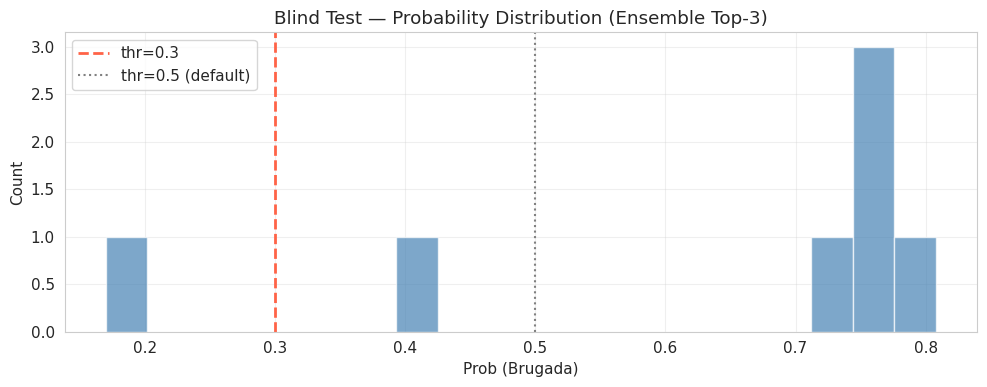

In [66]:
# ============================================================
# CELL 20 — BLIND TEST PREDICTION (label=2, uncertain)
# Ensemble of the top-3 models with the manual threshold
# ============================================================
print('Predicting BLIND TEST (brugada=2, uncertain patients)...')

blind_pids_valid = [pid for pid in blind_meta['patient_id'].values if pid in signals_v123]
print(f'Blind test: {len(blind_pids_valid)} patients')

if blind_pids_valid:
    blind_trad_rows = [extract_traditional_features(signals_v123[pid], FS)
                       for pid in blind_pids_valid]
    df_blind_trad = pd.DataFrame(blind_trad_rows).replace([np.inf,-np.inf], np.nan)
    for col in df_trad_all.columns:
        if col not in df_blind_trad.columns: df_blind_trad[col] = 0
    X_blind_trad = df_blind_trad[df_trad_all.columns].values.astype(float)

    blind_dummy = [0]*len(blind_pids_valid)
    X_blind_emb = extract_embeddings(backbone, blind_pids_valid, blind_dummy, signals_v123)
    X_blind_hyb = np.hstack([X_blind_trad, X_blind_emb])

    blind_feat_map = {
        'Traditional':  X_blind_trad,
        'DL_Embedding': X_blind_emb,
        'Hybrid':       X_blind_hyb,
    }

    top3 = df_rank.head(3)[['feature_set','model']].values
    all_probs = []
    for feat_n, model_n in top3:
        pipe_m = trained_models[f'{feat_n}|{model_n}']
        pr = pipe_m.predict_proba(blind_feat_map[feat_n])[:,1]
        all_probs.append(pr)
        print(f'  {feat_n}|{model_n}: {(pr>=MANUAL_THRESHOLD).sum()} suspected Brugada')

    blind_prob_ens = np.mean(all_probs, axis=0)

    df_blind_pred = pd.DataFrame({
        'patient_id':    blind_pids_valid,
        'prob_brugada':  np.round(blind_prob_ens, 4),
        'pred_default':  (blind_prob_ens>=0.5).astype(int),
        f'pred_thr{int(MANUAL_THRESHOLD*100):02d}': (blind_prob_ens>=MANUAL_THRESHOLD).astype(int),
        'flag': [f'⚠️ BRUGADA SUSPECTED (prob={p:.3f})'
                  if p>=MANUAL_THRESHOLD else f'✅ Likely Normal (prob={p:.3f})'
                  for p in blind_prob_ens]
    }).sort_values('prob_brugada', ascending=False)

    print(f'\nBlind Test Predictions (thr={MANUAL_THRESHOLD}):')
    print(df_blind_pred.to_string(index=False))
    df_blind_pred.to_csv('blind_test_predictions.csv', index=False)

    # Probability distribution
    fig, ax = plt.subplots(figsize=(10,4))
    ax.hist(blind_prob_ens, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(MANUAL_THRESHOLD, color='tomato', lw=2, linestyle='--',
               label=f'thr={MANUAL_THRESHOLD}')
    ax.axvline(0.5, color='gray', lw=1.5, linestyle=':', label='thr=0.5 (default)')
    ax.set_xlabel('Prob (Brugada)'); ax.set_ylabel('Count')
    ax.set_title('Blind Test — Probability Distribution (Ensemble Top-3)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## 21. Saving Results and Final Summary

All results are exported so they can be used for:
- report writing,
- further analysis,
- and experiment documentation.

### Overall notebook summary
- **Best in CV**: `DL_Embedding + ExtraTrees`
- **Best final model on the held-out test set**: `Traditional + RF`
- **Most important insight**: the model that looks strongest on train/CV is not necessarily the best when it meets new data.
- **Clinical insight**: threshold 0.30 helps reduce FN and successfully flags one borderline case during blind inference.

In [67]:
# ============================================================
# CELL 21 — SAVE ALL RESULTS + FINAL SUMMARY
# ============================================================
df_cv.to_csv('cv_fold_results.csv', index=False)
cv_summary.to_csv('cv_summary.csv', index=False)
df_test.to_csv('test_results.csv', index=False)
df_rank.to_csv('final_ranking.csv', index=False)

print('Saved:')
print('  cv_fold_results.csv      — raw fold-level CV metrics (default & manual thr)')
print('  cv_summary.csv           — aggregated CV mean±std per combo')
print('  test_results.csv         — test set results (default & manual thr)')
print('  final_ranking.csv        — final ranking by recall (manual thr)')
print('  blind_test_predictions.csv')

print('\n' + '='*70)
print('FINAL SUMMARY')
print('='*70)

top3 = df_rank.head(3)[['rank','feature_set','model',
                          'man_recall','man_pr_auc','man_roc_auc',
                          'man_accuracy','man_FN']]
print(f'''
V1-V2-V3 FOCUSED BRUTE FORCE RESULTS
======================================
Feature Sets  : Traditional | DL_Embedding | Hybrid
Models        : {', '.join(MODEL_NAMES)}
Total combos  : {len(MODEL_NAMES)} × 3 = {len(MODEL_NAMES)*3}

CV Strategy   : 5-Fold StratifiedKFold (SMOTE + imputer per fold, no leakage)
Final Eval    : Retrained on full train → held-out test (20%)
Threshold     : MANUAL = {MANUAL_THRESHOLD} (rule-based, no OOF tuning)

Priority Metric: RECALL  (minimize FN → minimize sudden death risk!)
Secondary      : AUCPR, ROC-AUC, F1

TOP-3 FINAL MODELS:
{top3.to_string(index=False)}
''')


Saved:
  cv_fold_results.csv      — raw fold-level CV metrics (default & manual thr)
  cv_summary.csv           — aggregated CV mean±std per combo
  test_results.csv         — test set results (default & manual thr)
  final_ranking.csv        — final ranking by recall (manual thr)
  blind_test_predictions.csv

FINAL SUMMARY

V1-V2-V3 FOCUSED BRUTE FORCE RESULTS
Feature Sets  : Traditional | DL_Embedding | Hybrid
Models        : LR, LR_C01, LR_C10, RF, ExtraTrees, XGB, XGB_reg, LGBM, MLP, SVM_rbf
Total combos  : 10 × 3 = 30

CV Strategy   : 5-Fold StratifiedKFold (SMOTE + imputer per fold, no leakage)
Final Eval    : Retrained on full train → held-out test (20%)
Threshold     : MANUAL = 0.3 (rule-based, no OOF tuning)

Priority Metric: RECALL  (minimize FN → minimize sudden death risk!)
Secondary      : AUCPR, ROC-AUC, F1

TOP-3 FINAL MODELS:
 rank  feature_set      model  man_recall  man_pr_auc  man_roc_auc  man_accuracy  man_FN
    1  Traditional         RF    0.714286    0.725450    

## Conclusion and Guide to Reading the Notebook

This notebook presents a complete experimental process, from signal cleaning to interpretation of the best model.

### Main conclusions
1. **Traditional features + Random Forest** is the best combination on the held-out test set.
2. **Deep learning embeddings** are very strong in cross-validation, but show a larger generalization gap.
3. The top features in the best model come from **V1-V2** and the **ST/T-wave** region, which aligns with the clinical understanding of Brugada.
4. Threshold **0.30** is not just a technical setting, but a design decision that improves screening sensitivity and helps capture borderline cases.

### How to read the notebook results
- Use **CV** to identify promising model candidates.
- Use the **held-out test set** to determine the final model.
- Use **feature importance** and **blind inference** to assess whether the model is not only accurate, but also clinically meaningful.

> In short, this notebook supports one main message:  
> **on small medical datasets, simpler models grounded in domain knowledge can be a safer and more trustworthy choice for screening.**